In [32]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
from collections import Counter

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from scipy.stats import mannwhitneyu

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

## 1. Генерация синтетических тестовых данных
пока что сделал simple вариант, тк схожую синтетику ещё не успел сделать (очень много влияющих факторов, тк оч много атрибутов) + очень увеличивается время выполнения кода тк компаний 200к


Создаём датасет с ~120 компаниями × 28 snapshot_date (январь 2024 — март 2026).
В данные заложены:
- **Нормальные компании** (~85%)
- **Подозрительные компании** (~15%) — с паттернами мошенничества:
  - Взрывной рост выручки при молодой компании
  - Несоответствие ОКВЭД бенефициаров
  - Смена бенефициаров/собственников/сегмента
  - Регион ТБ не совпадает с регистрацией
  - Высокая просрочка и реструктуризации
  - Ликвидированные бенефициары
  - Выбросы в суммах кредитов

In [5]:
np.random.seed(42)

# ─── Параметры ───
N_COMPANIES = 120
FRAUD_RATIO = 0.15
N_FRAUD = int(N_COMPANIES * FRAUD_RATIO)
N_NORMAL = N_COMPANIES - N_FRAUD

snapshot_dates = pd.date_range('2024-01-31', '2026-03-31', freq='ME')
N_SNAPSHOTS = len(snapshot_dates)  # 27 snapshots (end-of-month)

# Если нужно ровно 28, добавим 2026-03-31 вручную
if len(snapshot_dates) < 28:
    extra = pd.to_datetime('2026-03-31')
    if extra not in snapshot_dates:
        snapshot_dates = snapshot_dates.append(pd.DatetimeIndex([extra]))
N_SNAPSHOTS = len(snapshot_dates)

print(f"Компаний: {N_COMPANIES} (нормальных: {N_NORMAL}, подозрительных: {N_FRAUD})")
print(f"Snapshot dates: {N_SNAPSHOTS} (с {snapshot_dates[0].strftime('%Y-%m-%d')} по {snapshot_dates[-1].strftime('%Y-%m-%d')})")

# ─── Справочники ───
OKVED_SECTIONS = list('ABCDEFGHIJKLMNOPQRS')
OKVED_NAMES = {
    'A': 'Сельское хозяйство', 'B': 'Добыча полезных ископаемых',
    'C': 'Обрабатывающие производства', 'D': 'Электроэнергия',
    'E': 'Водоснабжение', 'F': 'Строительство',
    'G': 'Торговля', 'H': 'Транспортировка', 'I': 'Гостиницы',
    'J': 'Информация и связь', 'K': 'Финансовая деятельность',
    'L': 'Недвижимость', 'M': 'Научная деятельность',
    'N': 'Административная деятельность', 'O': 'Гос. управление',
    'P': 'Образование', 'Q': 'Здравоохранение', 'R': 'Культура', 'S': 'Прочие услуги'
}
TERBANKS = ['Московский', 'Северо-Западный', 'Волго-Вятский', 'Уральский',
            'Сибирский', 'Дальневосточный', 'Центральный', 'Юго-Западный',
            'Поволжский', 'Байкальский']
REGIONS = ['Москва', 'Санкт-Петербург', 'Новосибирская обл.', 'Свердловская обл.',
           'Краснодарский край', 'Татарстан', 'Нижегородская обл.', 'Самарская обл.',
           'Ростовская обл.', 'Красноярский край', 'Воронежская обл.', 'Пермский край',
           'Иркутская обл.', 'Приморский край', 'Тюменская обл.']
SEGMENTS = ['Крупный бизнес', 'Средний бизнес', 'Малый бизнес', 'Микробизнес']
RISK_SEGMENTS = ['Низкий', 'Средний', 'Повышенный', 'Высокий']
ORG_SECTORS = ['Энергетика', 'Металлургия', 'Нефтегаз', 'Торговля', 'Строительство',
               'IT', 'Транспорт', 'АПК', 'Фармацевтика', 'Финансы']
LIQUIDATION_STATUSES = ['Действующее', 'В стадии ликвидации', 'Ликвидировано']
PROBLEM_GROUPS = ['Без признаков', 'Потенциально проблемные', 'Проблемные', 'Безнадёжные']
AGR_TYPES = ['КЛЗ', 'КД', 'ГР', 'ОВ', 'КЛВ']
PRODUCTS = ['Кредитная линия', 'Кредит', 'Гарантия', 'Овердрафт', 'Проектное финансирование']
FRD_SCHEME_CODES = [None, 'SCHEME_01', 'SCHEME_02', 'SCHEME_03', 'SCHEME_04']
FRD_STAGES = [None, 'Выявление', 'Расследование', 'Завершено']
FRD_SRC_CODES = [None, 'MANUAL', 'AUTO', 'EXTERNAL']
CLAIM_STATUSES = [None, 'Наблюдение', 'Конкурсное производство', 'Финансовое оздоровление']

# ─── Генерация INN ───
def gen_inn():
    return str(np.random.randint(1000000000, 9999999999, dtype=np.int64))

inns = [gen_inn() for _ in range(N_COMPANIES)]
is_fraud = [False] * N_NORMAL + [True] * N_FRAUD
np.random.shuffle(is_fraud)
inn_fraud_map = dict(zip(inns, is_fraud))

# ─── Генерация данных ───
rows = []
for idx, inn in enumerate(inns):
    fraud = inn_fraud_map[inn]
    org_id = 100000 + idx
    okved_section = np.random.choice(OKVED_SECTIONS)
    okved_cd = f"{okved_section}{np.random.randint(1,99):02d}.{np.random.randint(1,99):02d}"
    okved_name = OKVED_NAMES.get(okved_section, 'Прочее')
    terbank = np.random.choice(TERBANKS)
    reg_region = np.random.choice(REGIONS)
    segment = np.random.choice(SEGMENTS)
    org_sector = np.random.choice(ORG_SECTORS)
    risk_seg = np.random.choice(RISK_SEGMENTS, p=[0.4, 0.3, 0.2, 0.1])
    gsz_name = f"ГСЗ_{np.random.randint(1, 50)}" if np.random.random() > 0.3 else None

    # Бенефициары
    has_ben_0 = 1 if np.random.random() > 0.2 else 0
    has_ben_1 = 1 if np.random.random() > 0.5 else 0
    has_ben_3 = 1 if np.random.random() > 0.7 else 0
    has_ben_5 = 1 if np.random.random() > 0.85 else 0
    inn_ben_0 = gen_inn() if has_ben_0 else None
    inn_ben_1 = gen_inn() if has_ben_1 else None
    okved_section_ben_0 = np.random.choice(OKVED_SECTIONS) if has_ben_0 else None
    okved_section_ben_1 = np.random.choice(OKVED_SECTIONS) if has_ben_1 else None

    # Кредитные параметры (базовые)
    base_limit = np.random.lognormal(mean=17, sigma=1.5)  # ~24M median
    base_debt = base_limit * np.random.uniform(0.3, 0.95)

    # Договор
    signed_dt = pd.Timestamp('2020-01-01') + pd.Timedelta(days=np.random.randint(0, 1500))
    expiration_dt = signed_dt + pd.Timedelta(days=np.random.randint(365, 2555))
    issue_dt = signed_dt + pd.Timedelta(days=np.random.randint(0, 30))
    doc_number = f"КД-{np.random.randint(100000, 999999)}"

    # Фрод-параметры для подозрительных
    if fraud:
        risk_seg = np.random.choice(['Повышенный', 'Высокий'], p=[0.4, 0.6])
        # Взрывной рост выручки
        frd_jump_score = np.random.uniform(0.6, 1.0)
        max_growth_pct = np.random.uniform(200, 2000)
        prev_revenue = np.random.uniform(1e6, 5e7)
        jump_revenue = prev_revenue * (1 + max_growth_pct / 100)
        jump_year = np.random.choice([2023, 2024, 2025])
        # Несоответствие ОКВЭД
        okved_section_ben_0 = np.random.choice([s for s in OKVED_SECTIONS if s != okved_section]) if has_ben_0 else None
        okved_section_ben_1 = np.random.choice([s for s in OKVED_SECTIONS if s != okved_section]) if has_ben_1 else None
    else:
        frd_jump_score = np.random.uniform(0, 0.3) if np.random.random() > 0.7 else 0
        max_growth_pct = np.random.uniform(0, 80) if frd_jump_score > 0 else None
        prev_revenue = np.random.uniform(1e7, 5e9) if np.random.random() > 0.3 else None
        jump_revenue = prev_revenue * (1 + max_growth_pct / 100) if (prev_revenue and max_growth_pct) else None
        jump_year = np.random.choice([2022, 2023, 2024]) if frd_jump_score > 0.1 else None

    for snap_idx, snap_dt in enumerate(snapshot_dates):
        row = {}
        row['org_id'] = org_id
        row['snapshot_date'] = snap_dt
        row['start_dt_ckp'] = signed_dt - pd.Timedelta(days=np.random.randint(0, 365))
        row['end_dt_ckp'] = expiration_dt + pd.Timedelta(days=np.random.randint(0, 730)) if np.random.random() > 0.5 else None
        row['fact_address'] = f"г. {np.random.choice(['Москва','СПб','Казань','Новосибирск','Екатеринбург'])}, ул. Тестовая, д. {np.random.randint(1,100)}" if np.random.random() > 0.1 else None
        row['inn'] = inn
        row['okved_cd'] = okved_cd
        row['okved_name'] = okved_name
        row['okved_section'] = okved_section
        row['terbank'] = terbank
        row['org_sector'] = org_sector
        row['liquidation'] = 'Действующее' if not fraud else np.random.choice(LIQUIDATION_STATUSES, p=[0.6, 0.25, 0.15])
        row['okk_code'] = f"OKK_{np.random.randint(100,999)}" if np.random.random() > 0.3 else None
        row['risk_segment'] = risk_seg
        row['gsz_name'] = gsz_name
        row['reg_region'] = reg_region
        row['reg_region_norm'] = reg_region
        # ТБ совпадение с регионом
        if fraud:
            row['frd_terbank_reg_match'] = np.random.choice([0, 1, 2], p=[0.6, 0.2, 0.2])
        else:
            row['frd_terbank_reg_match'] = np.random.choice([0, 1, 2], p=[0.1, 0.8, 0.1])
        row['segment_name'] = segment
        # Смена сегмента
        if fraud:
            row['frd_segment_changed_1y'] = np.random.choice([0, 1], p=[0.3, 0.7])
            row['frd_segment_changed_2y'] = np.random.choice([0, 1], p=[0.2, 0.8])
            row['frd_reject_diff_segment_2y'] = np.random.choice([0, 1], p=[0.4, 0.6])
        else:
            row['frd_segment_changed_1y'] = np.random.choice([0, 1], p=[0.9, 0.1])
            row['frd_segment_changed_2y'] = np.random.choice([0, 1], p=[0.85, 0.15])
            row['frd_reject_diff_segment_2y'] = np.random.choice([0, 1], p=[0.95, 0.05])

        # Реструктуризация
        row['last_restruct_dt'] = snap_dt - pd.Timedelta(days=np.random.randint(30, 365)) if (fraud and np.random.random() > 0.3) or np.random.random() > 0.9 else None

        # Судебные дела
        if fraud and np.random.random() > 0.4:
            row['claim_sum'] = np.random.uniform(1e6, 5e8)
            row['claim_date'] = snap_dt - pd.Timedelta(days=np.random.randint(30, 730))
            row['b_claim_status'] = np.random.choice(CLAIM_STATUSES)
            row['claim_num'] = f"А40-{np.random.randint(10000,99999)}/{snap_dt.year}"
            row['case_end_dt'] = None if np.random.random() > 0.5 else snap_dt + pd.Timedelta(days=np.random.randint(30, 365))
            row['wasbankrupt'] = snap_dt - pd.Timedelta(days=np.random.randint(365, 1825)) if np.random.random() > 0.6 else None
            row['m_claim_sum'] = np.random.uniform(1e5, 1e8)
            row['claim_count'] = np.random.randint(1, 15)
        else:
            for c in ['claim_sum','claim_date','b_claim_status','claim_num','case_end_dt','wasbankrupt','m_claim_sum','claim_count']:
                row[c] = None
            if not fraud and np.random.random() > 0.85:
                row['claim_sum'] = np.random.uniform(1e4, 5e6)
                row['claim_count'] = np.random.randint(1, 3)

        # Выручка
        row['jump_year'] = jump_year
        row['frd_jump_score'] = round(frd_jump_score, 4) if frd_jump_score else None
        row['max_growth_pct'] = round(max_growth_pct, 2) if max_growth_pct else None
        row['prev_revenue'] = round(prev_revenue, 2) if prev_revenue else None
        row['jump_revenue'] = round(jump_revenue, 2) if jump_revenue else None
        row['max_growth_rub'] = round(jump_revenue - prev_revenue, 2) if (jump_revenue and prev_revenue) else None

        # Фрод-реестр
        if fraud and np.random.random() > 0.5:
            row['frd_scheme_code'] = np.random.choice(FRD_SCHEME_CODES[1:])
            row['frd_rgstr_sid'] = np.random.randint(10000, 99999)
            row['frdsgn_stts_code'] = np.random.choice(['CONFIRMED', 'SUSPECTED', 'INVESTIGATION'])
            row['frd_stg_name'] = np.random.choice(FRD_STAGES[1:])
            row['frd_src_code'] = np.random.choice(FRD_SRC_CODES[1:])
            row['frd_start_dt'] = snap_dt - pd.Timedelta(days=np.random.randint(30, 730))
            row['frdsgn_imp_on_dflt_flag'] = np.random.choice([0, 1])
            row['frd_check_end_dt'] = snap_dt + pd.Timedelta(days=np.random.randint(0, 180)) if np.random.random() > 0.5 else None
            row['frd_susp_flag'] = 1
        else:
            for c in ['frd_scheme_code','frd_rgstr_sid','frdsgn_stts_code','frd_stg_name',
                       'frd_src_code','frd_start_dt','frdsgn_imp_on_dflt_flag','frd_check_end_dt']:
                row[c] = None
            row['frd_susp_flag'] = 0

        # Бенефициары
        row['inn_benef_0'] = inn_ben_0
        row['benef_ip_0'] = 'ЮЛ' if has_ben_0 and np.random.random() > 0.3 else ('ИП' if has_ben_0 else None)
        row['okved_cd_benef_0'] = f"{okved_section_ben_0}{np.random.randint(1,99):02d}.{np.random.randint(1,99):02d}" if okved_section_ben_0 else None
        row['okved_name_benef_ip_0'] = OKVED_NAMES.get(okved_section_ben_0) if okved_section_ben_0 else None
        row['okved_section_benef_0'] = okved_section_ben_0
        row['frd_liquidation_ben_0'] = np.random.choice(LIQUIDATION_STATUSES, p=[0.5, 0.3, 0.2]) if (fraud and has_ben_0) else ('Действующее' if has_ben_0 else None)
        row['inn_benef_1'] = inn_ben_1
        row['benef_ip_1'] = 'ЮЛ' if has_ben_1 and np.random.random() > 0.3 else ('ИП' if has_ben_1 else None)
        row['okved_cd_benef_1'] = f"{okved_section_ben_1}{np.random.randint(1,99):02d}.{np.random.randint(1,99):02d}" if okved_section_ben_1 else None
        row['okved_name_benef_ip_1'] = OKVED_NAMES.get(okved_section_ben_1) if okved_section_ben_1 else None
        row['okved_section_benef_1'] = okved_section_ben_1
        row['liquidation_ben_1'] = np.random.choice(LIQUIDATION_STATUSES, p=[0.5, 0.3, 0.2]) if (fraud and has_ben_1) else ('Действующее' if has_ben_1 else None)

        row['ben_0'] = has_ben_0
        row['ben_1'] = has_ben_1
        row['ben_3'] = has_ben_3
        row['ben_5'] = has_ben_5
        row['frd_ben_0_changed'] = np.random.choice([0, 1], p=[0.3, 0.7]) if fraud else np.random.choice([0, 1], p=[0.9, 0.1])

        row['epk_owner'] = np.random.randint(100000000, 999999999) if np.random.random() > 0.1 else None
        row['epk_director'] = np.random.randint(100000000, 999999999) if np.random.random() > 0.1 else None
        row['frd_owner_changed_1y'] = np.random.choice([0, 1], p=[0.2, 0.8]) if fraud else np.random.choice([0, 1], p=[0.92, 0.08])

        row['doc_number'] = doc_number
        row['signed_dt'] = signed_dt
        row['expiration_dt'] = expiration_dt
        row['issue_dt'] = issue_dt
        row['agr_regls_type_codes'] = np.random.choice(AGR_TYPES)
        row['grntee_prod_name'] = np.random.choice(PRODUCTS)

        # Финансовые показатели (с трендом для фрода)
        time_factor = 1 + snap_idx * 0.02  # Лёгкий рост по времени
        noise = np.random.normal(1, 0.1)

        if fraud:
            # Для мошенников: рост долга, появление просрочки
            debt_mult = 1 + snap_idx * np.random.uniform(0.03, 0.08)
            row['debt_due_rub'] = round(base_debt * debt_mult * noise, 2)
            # Просрочка растёт со временем
            ovr_prob = min(0.9, 0.1 + snap_idx * 0.03)
            row['debt_ovr_rub'] = round(base_debt * np.random.uniform(0.05, 0.4) * debt_mult, 2) if np.random.random() < ovr_prob else 0
            # Выбросы
            if np.random.random() > 0.92:
                row['debt_due_rub'] *= np.random.uniform(3, 10)
                row['debt_ovr_rub'] *= np.random.uniform(2, 8)
        else:
            row['debt_due_rub'] = round(base_debt * time_factor * noise, 2) if np.random.random() > 0.05 else None
            row['debt_ovr_rub'] = round(base_debt * np.random.uniform(0, 0.05), 2) if np.random.random() > 0.85 else 0

        row['util_limit_amt'] = round(base_limit * np.random.uniform(0.5, 1.0), 2) if np.random.random() > 0.1 else None
        row['exposure_amt'] = round(base_limit * np.random.uniform(0.6, 1.2), 2)
        row['limit_amt'] = round(base_limit, 2)
        row['restruct_cnt'] = np.random.choice([0, 1, 2, 3, 4], p=[0.2, 0.2, 0.2, 0.2, 0.2]) if fraud else np.random.choice([0, 0, 0, 0, 1], p=[0.7, 0.1, 0.1, 0.05, 0.05])
        row['problem_group'] = np.random.choice(PROBLEM_GROUPS, p=[0.2, 0.3, 0.3, 0.2]) if fraud else np.random.choice(PROBLEM_GROUPS, p=[0.7, 0.2, 0.08, 0.02])
        row['ovr_cnt'] = np.random.randint(0, 12) if fraud else np.random.randint(0, 2)

        # Дефолт
        if fraud and np.random.random() > 0.5:
            row['default_start_dt'] = snap_dt - pd.Timedelta(days=np.random.randint(30, 365))
            row['default_end_dt'] = None if np.random.random() > 0.5 else snap_dt - pd.Timedelta(days=np.random.randint(0, 30))
        else:
            row['default_start_dt'] = None
            row['default_end_dt'] = None

        # Расчётные поля
        expo = round(base_debt * time_factor * np.random.uniform(0.9, 1.1), 2)
        row['expo_calc'] = expo
        row['reserv_prud_calc'] = round(expo * np.random.uniform(0.05, 0.5 if fraud else 0.15), 2)
        row['reserv_ocen_calc'] = round(expo * np.random.uniform(0.03, 0.4 if fraud else 0.12), 2)
        row['od_calc'] = round(expo * np.random.uniform(0.8, 1.0), 2)
        row['due_od_calc'] = round(row['od_calc'] * np.random.uniform(0.7, 1.0), 2)
        row['overdue_od_calc'] = round(row['od_calc'] - row['due_od_calc'], 2)

        # ОКВЭД diff флаги
        row['frd_okved_section_diff_benef_0'] = 1 if (okved_section_ben_0 and okved_section_ben_0 != okved_section) else 0
        row['frd_okved_section_diff_benef_1'] = 1 if (okved_section_ben_1 and okved_section_ben_1 != okved_section) else 0
        row['frd_okved_cd_diff_benef_0'] = row['frd_okved_section_diff_benef_0']  # Simplified
        row['frd_okved_cd_diff_benef_1'] = row['frd_okved_section_diff_benef_1']

        rows.append(row)

df = pd.DataFrame(rows)

# Добавим None случайным образом в ~5% ячеек (для числовых полей)
numeric_cols_for_nulls = ['claim_sum', 'claim_count', 'prev_revenue', 'jump_revenue',
                          'util_limit_amt', 'expo_calc', 'reserv_prud_calc']
for col in numeric_cols_for_nulls:
    mask = np.random.random(len(df)) < 0.08
    df.loc[mask, col] = None

print(f"Датасет: {df.shape[0]} строк × {df.shape[1]} столбцов")
print(f"Уникальных ИНН: {df['inn'].nunique()}")
print(f"Snapshot dates: {df['snapshot_date'].nunique()}")
df.head(3)

Компаний: 120 (нормальных: 102, подозрительных: 18)
Snapshot dates: 27 (с 2024-01-31 по 2026-03-31)
Датасет: 3240 строк × 92 столбцов
Уникальных ИНН: 120
Snapshot dates: 27


,org_id,snapshot_date,start_dt_ckp,end_dt_ckp,fact_address,inn,okved_cd,okved_name,okved_section,terbank,org_sector,liquidation,okk_code,risk_segment,gsz_name,reg_region,reg_region_norm,frd_terbank_reg_match,segment_name,frd_segment_changed_1y,frd_segment_changed_2y,frd_reject_diff_segment_2y,last_restruct_dt,claim_sum,claim_date,b_claim_status,claim_num,case_end_dt,wasbankrupt,m_claim_sum,claim_count,jump_year,frd_jump_score,max_growth_pct,prev_revenue,jump_revenue,max_growth_rub,frd_scheme_code,frd_rgstr_sid,frdsgn_stts_code,frd_stg_name,frd_src_code,frd_start_dt,frdsgn_imp_on_dflt_flag,frd_check_end_dt,frd_susp_flag,inn_benef_0,benef_ip_0,okved_cd_benef_0,okved_name_benef_ip_0,okved_section_benef_0,frd_liquidation_ben_0,inn_benef_1,benef_ip_1,okved_cd_benef_1,okved_name_benef_ip_1,okved_section_benef_1,liquidation_ben_1,ben_0,ben_1,ben_3,ben_5,frd_ben_0_changed,epk_owner,epk_director,frd_owner_changed_1y,doc_number,signed_dt,expiration_dt,issue_dt,agr_regls_type_codes,grntee_prod_name,debt_due_rub,debt_ovr_rub,util_limit_amt,exposure_amt,limit_amt,restruct_cnt,problem_group,ovr_cnt,default_start_dt,default_end_dt,expo_calc,reserv_prud_calc,reserv_ocen_calc,od_calc,due_od_calc,overdue_od_calc,frd_okved_section_diff_benef_0,frd_okved_section_diff_benef_1,frd_okved_cd_diff_benef_0,frd_okved_cd_diff_benef_1
0,100000,2024-01-31,2023-09-08,NaT,None,1787846414,J19.58,Информация и связь,J,Московский,Торговля,Действующее,OKK_826,Средний,ГСЗ_2,Самарская обл.,Самарская обл.,0,Крупный бизнес,0,0,0,NaT,NaN,NaT,None,None,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,None,None,None,NaT,NaN,NaT,0,None,None,None,None,None,None,7757559970,ИП,A75.29,Сельское хозяйство,A,Действующее,0,1,1,0,0,237587448.00,845052004.00,0,КД-707274,2023-12-11,2028-03-15,2023-12-20,ГР,Кредитная линия,434718776.32,0.00,468090392.13,663553311.77,592315542.59,0,Без признаков,0,NaT,NaT,567265692.85,71165913.27,22282847.75,556210014.27,473654938.78,82555075.49,0,1,0,1
1,100000,2024-02-29,2023-05-09,NaT,"г. Москва, ул. Тестовая, д. 12",1787846414,J19.58,Информация и связь,J,Московский,Торговля,Действующее,OKK_175,Средний,ГСЗ_2,Самарская обл.,Самарская обл.,1,Крупный бизнес,1,0,0,NaT,NaN,NaT,None,None,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,None,None,None,NaT,NaN,NaT,0,None,None,None,None,None,None,7757559970,ИП,A12.25,Сельское хозяйство,A,Действующее,0,1,1,0,0,942649140.00,270158648.00,0,КД-707274,2023-12-11,2028-03-15,2023-12-20,КЛВ,Кредит,650893672.89,0.00,552887675.07,653376438.68,592315542.59,0,Без признаков,0,NaT,NaT,586433520.60,70738087.60,21886514.28,479097152.35,477176870.38,1920281.97,0,1,0,1
2,100000,2024-03-31,2022-12-12,NaT,"г. Москва, ул. Тестовая, д. 45",1787846414,J19.58,Информация и связь,J,Московский,Торговля,Действующее,OKK_169,Средний,ГСЗ_2,Самарская обл.,Самарская обл.,1,Крупный бизнес,0,0,0,NaT,NaN,NaT,None,None,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,None,None,None,NaT,NaN,NaT,0,None,None,None,None,None,None,7757559970,ЮЛ,A45.13,Сельское хозяйство,A,Действующее,0,1,1,0,0,610319067.00,412632190.00,0,КД-707274,2023-12-11,2028-03-15,2023-12-20,КЛЗ,Гарантия,584498206.36,10124568.68,553400153.25,434852899.80,592315542.59,1,Без признаков,1,NaT,NaT,568062344.49,46733715.85,19260761.90,559500887.19,545924438.47,13576448.72,0,1,0,1


In [33]:
# Сохраним тестовые данные
test_data_path = RAW_DATA_DIR / 'test_data.csv'
df.to_csv(test_data_path, index=False, sep=';')

# Сохраним ground truth отдельно (для оценки качества моделей)
test_gt_path = RAW_DATA_DIR / 'test_gt.csv'
gt = pd.DataFrame({'inn': list(inn_fraud_map.keys()), '_is_fraud': list(inn_fraud_map.values())})
gt['_is_fraud'] = gt['_is_fraud'].astype(int)
gt.to_csv(test_gt_path, index=False, sep=';')

print(f"Тестовые данные сохранены: {test_data_path}")
print(f"Ground truth сохранён: {test_gt_path} ({gt['_is_fraud'].sum()} подозрительных из {len(gt)})")

Тестовые данные сохранены: C:\Users\Egor\Desktop\hseml-group-project-gorg1t\data\raw\test_data.csv
Ground truth сохранён: C:\Users\Egor\Desktop\hseml-group-project-gorg1t\data\raw\test_gt.csv (18 подозрительных из 120)


---
## 2. Загрузка данных

Основная точка входа для аналитики. При работе с реальными данными — заменить путь к файлу.

In [34]:
# ─── Загрузка данных ───
DATA_PATH = RAW_DATA_DIR / 'test_data.csv'  # <-- заменить на путь к реальным данным в data/raw

df = pd.read_csv(DATA_PATH, sep=';', low_memory=False)

# Парсинг дат
date_cols = [c for c in df.columns if 'dt' in c.lower() or 'date' in c.lower()]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Приведение decimal-полей к float
decimal_cols = ['debt_due_rub','debt_ovr_rub','exposure_amt','limit_amt',
                'expo_calc','reserv_prud_calc','reserv_ocen_calc','restruct_cnt','ovr_cnt',
                'claim_sum','claim_count','overdue_od_calc','od_calc','due_od_calc',
                'util_limit_amt','m_claim_sum','frd_jump_score','max_growth_pct',
                'max_growth_rub','prev_revenue','jump_revenue']
for col in decimal_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f"Источник данных: {DATA_PATH}")
print(f"Загружено: {df.shape[0]} строк x {df.shape[1]} столбцов")
print(f"Уникальных ИНН: {df['inn'].nunique()}")
print(f"Snapshot dates: {df['snapshot_date'].nunique()}")

# Расширенный анализ пропусков
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(f"\nСтолбцы с 90%+ пропусков: {(missing >= 90).sum()}")
print(f"Столбцы с <10% пропусков: {(missing < 10).sum()}")
print(f"Полностью пустые столбцы: {(missing >= 99.99).sum()}")
print(f"\nДоля пропусков (топ-30):")
print(missing.head(30).to_string())

Источник данных: C:\Users\Egor\Desktop\hseml-group-project-gorg1t\data\raw\test_data.csv
Загружено: 3240 строк x 92 столбцов
Уникальных ИНН: 120
Snapshot dates: 27

Столбцы с 90%+ пропусков: 16
Столбцы с <10% пропусков: 50
Полностью пустые столбцы: 0

Доля пропусков (топ-30):
frd_check_end_dt          96.54
default_end_dt            96.45
case_end_dt               96.08
wasbankrupt               95.86
b_claim_status            92.90
frdsgn_imp_on_dflt_flag   92.84
frd_scheme_code           92.84
frd_stg_name              92.84
frd_src_code              92.84
frd_start_dt              92.84
frdsgn_stts_code          92.84
frd_rgstr_sid             92.84
default_start_dt          92.31
claim_date                91.17
m_claim_sum               91.17
claim_num                 91.17
claim_count               80.59
claim_sum                 80.43
last_restruct_dt          79.88
jump_revenue              73.02
jump_year                 71.67
max_growth_rub            70.83
max_growth_pct     

## 3. Разведочный анализ (EDA)

Анализируем распределения ключевых финансовых показателей и фрод-флагов.

In [8]:
# ─── Агрегация до уровня компании (последний snapshot) ───
df_last = df.sort_values('snapshot_date').groupby('inn').last().reset_index()
print(f"Компаний в последнем срезе: {len(df_last)}")

# ─── Описательная статистика ───
key_numeric = ['debt_due_rub','debt_ovr_rub','exposure_amt','limit_amt',
               'expo_calc','reserv_prud_calc','reserv_ocen_calc','restruct_cnt','ovr_cnt']
df_last[key_numeric].describe().T

Компаний в последнем срезе: 120


,count,mean,std,min,25%,50%,75%,max
debt_due_rub,120.00,86743732.25,318180558.59,789936.92,7717675.38,17169076.42,54322852.25,3259564478.55
debt_ovr_rub,120.00,1256880.47,4694516.99,0.00,0.00,0.00,192139.12,35833147.37
exposure_amt,120.00,77803387.33,311344409.58,836006.44,6852340.98,17958843.89,42697548.93,3271588385.42
limit_amt,120.00,86423226.05,320079186.71,922488.74,8164689.13,19456232.61,53381364.47,3310779127.32
expo_calc,120.00,88267052.23,348407531.57,748290.68,7188970.30,16329665.71,44390334.02,3584095242.69
reserv_prud_calc,120.00,8576308.30,23662424.91,69050.34,757976.26,1829730.02,6479351.82,220511881.83
reserv_ocen_calc,120.00,6348288.70,16411166.74,62927.41,575462.36,1342146.21,4447138.44,127586800.39
restruct_cnt,120.00,0.39,0.96,0.00,0.00,0.00,0.00,4.00
ovr_cnt,120.00,1.30,2.53,0.00,0.00,0.00,1.00,11.00


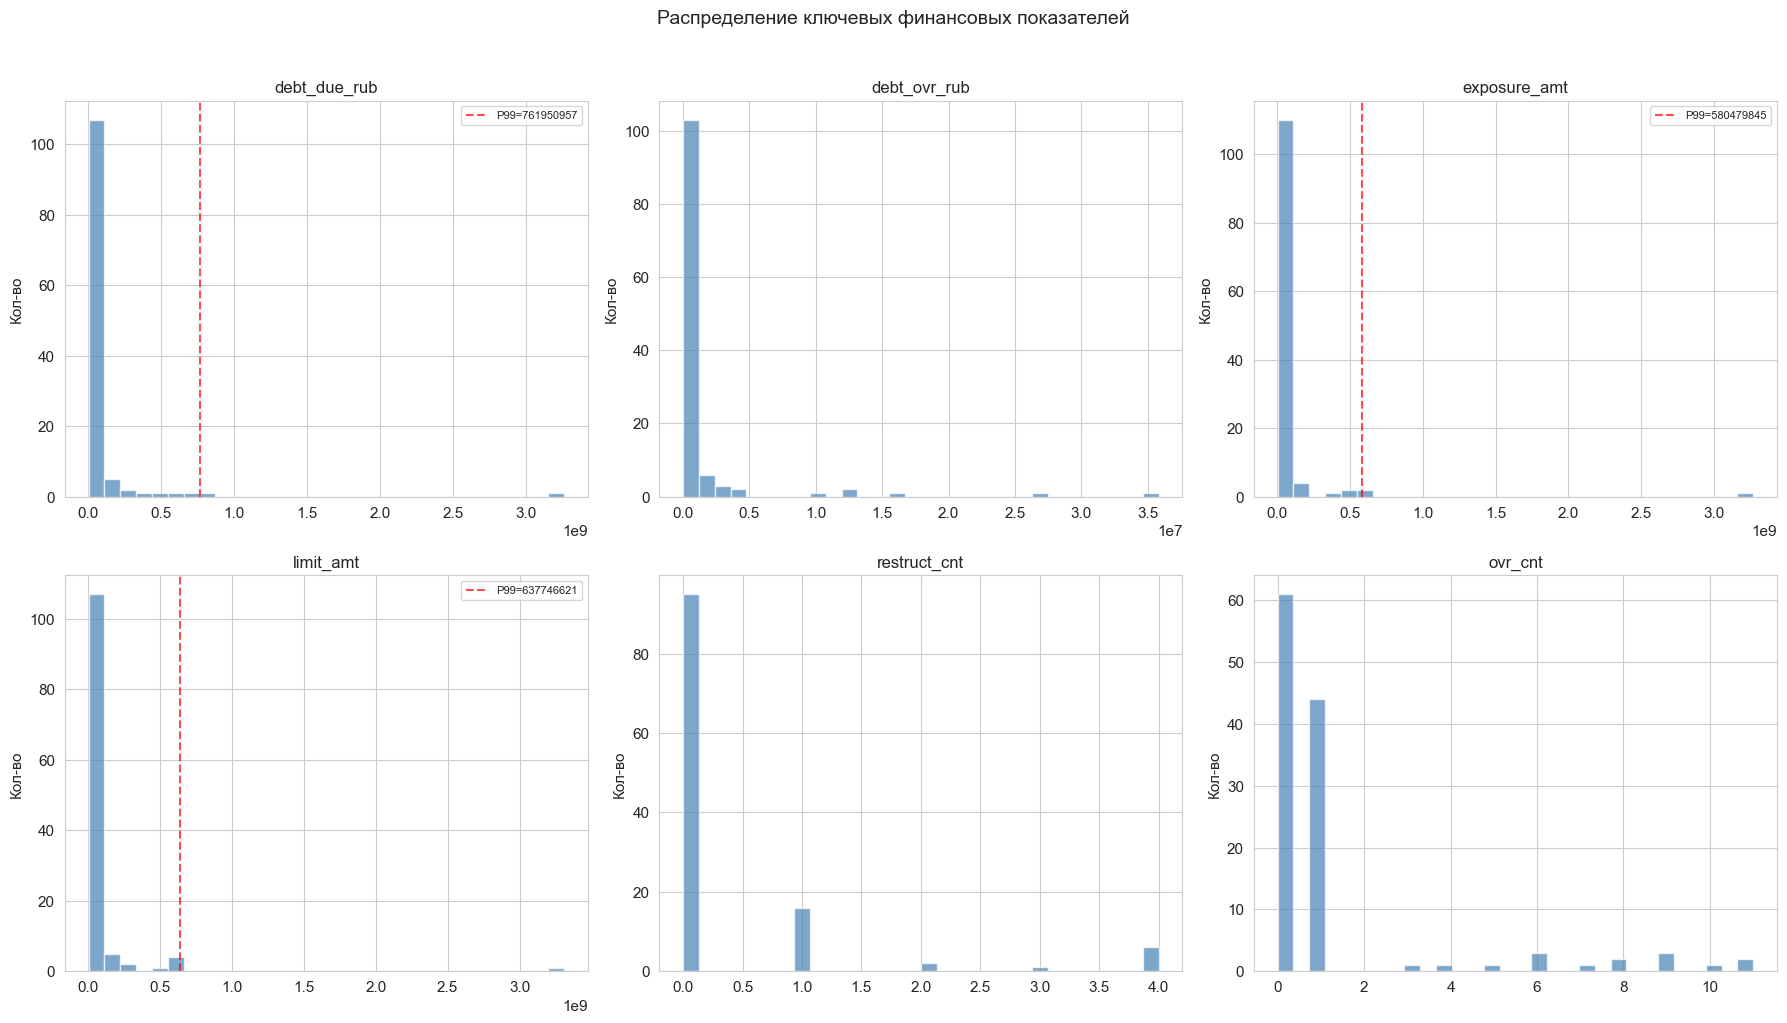

In [9]:
# ─── Распределения ключевых финансовых показателей ───
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flatten(), ['debt_due_rub','debt_ovr_rub','exposure_amt','limit_amt','restruct_cnt','ovr_cnt']):
    data = df_last[col].dropna()
    ax.hist(data, bins=30, alpha=0.7, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('Кол-во')
    # Отметим выбросы (>99-й перцентиль)
    if len(data) > 0:
        p99 = data.quantile(0.99)
        if data.max() > p99 * 1.5:
            ax.axvline(x=p99, color='red', linestyle='--', alpha=0.7, label=f'P99={p99:.0f}')
            ax.legend(fontsize=8)

plt.suptitle('Распределение ключевых финансовых показателей', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

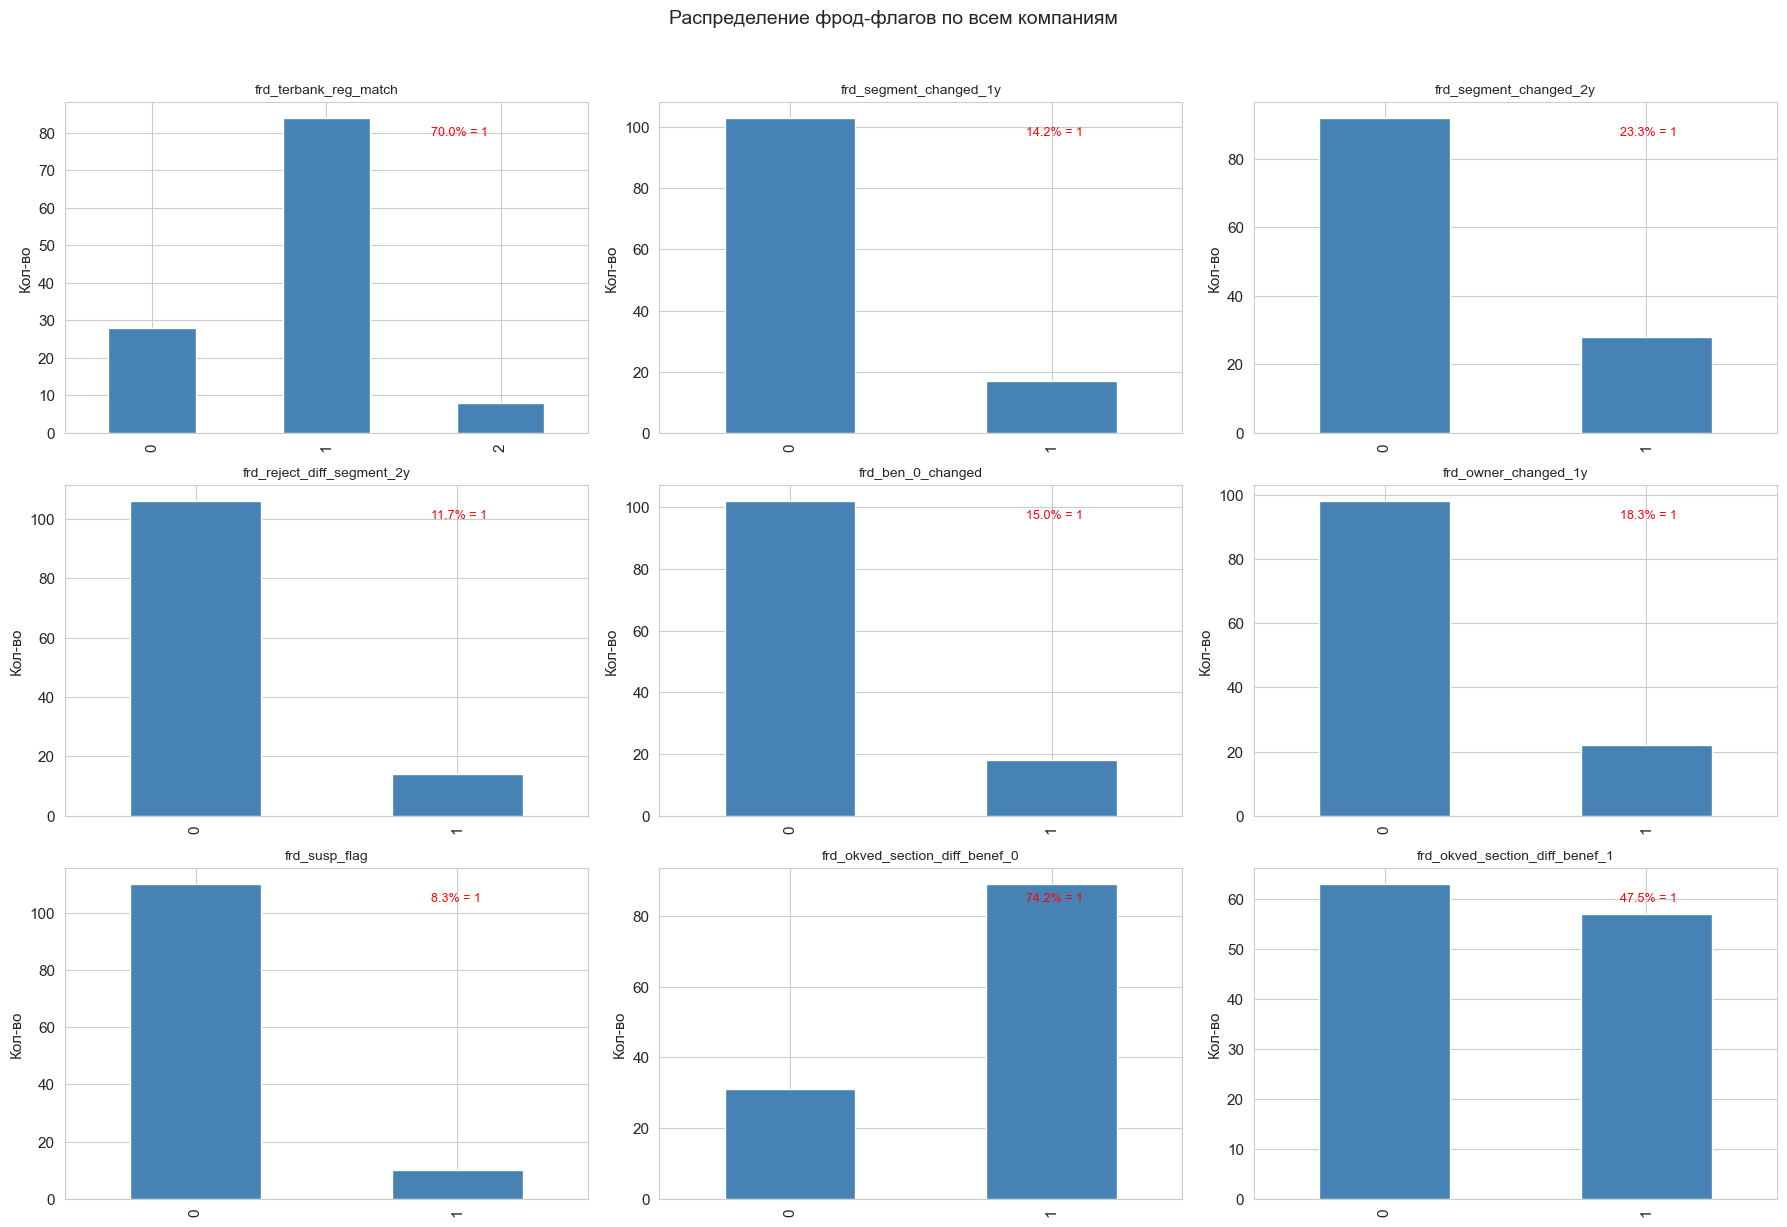

In [10]:
# ─── Фрод-флаги: распределение значений ───
frd_flags = ['frd_terbank_reg_match', 'frd_segment_changed_1y', 'frd_segment_changed_2y',
             'frd_reject_diff_segment_2y', 'frd_ben_0_changed', 'frd_owner_changed_1y',
             'frd_susp_flag', 'frd_okved_section_diff_benef_0', 'frd_okved_section_diff_benef_1']

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
for ax, flag in zip(axes.flatten(), frd_flags):
    counts = df_last[flag].value_counts().sort_index()
    counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(flag, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('Кол-во')
    # Доля "подозрительных" значений
    total = counts.sum()
    if 1 in counts.index:
        pct = counts.get(1, 0) / total * 100
        ax.annotate(f'{pct:.1f}% = 1', xy=(0.7, 0.9), xycoords='axes fraction', fontsize=9, color='red')

plt.suptitle('Распределение фрод-флагов по всем компаниям', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

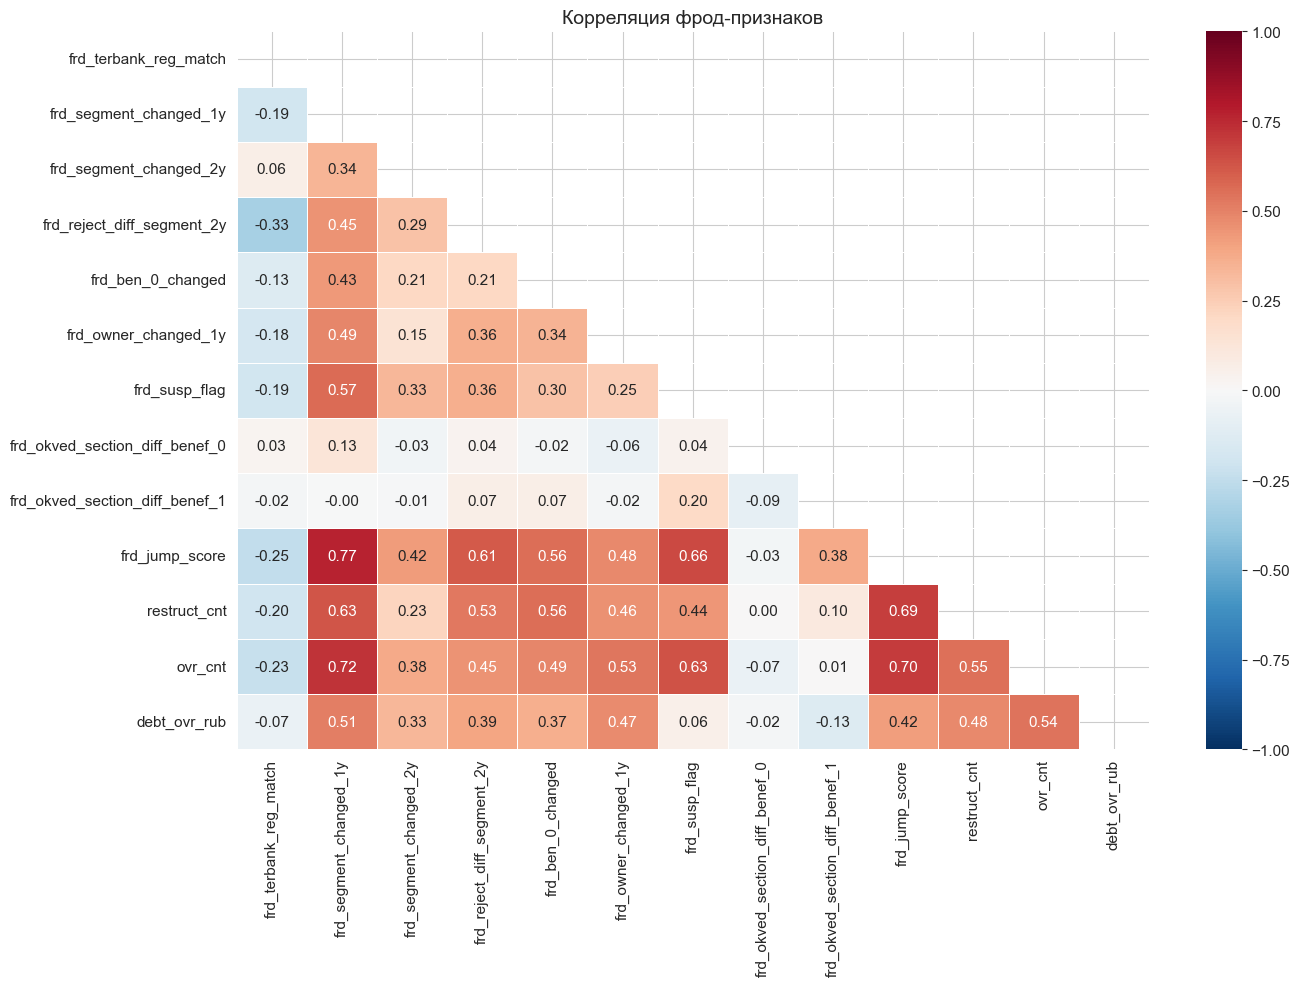

In [11]:
# ─── Корреляционная матрица фрод-релевантных признаков ───
corr_cols = ['frd_terbank_reg_match', 'frd_segment_changed_1y', 'frd_segment_changed_2y',
             'frd_reject_diff_segment_2y', 'frd_ben_0_changed', 'frd_owner_changed_1y',
             'frd_susp_flag', 'frd_okved_section_diff_benef_0', 'frd_okved_section_diff_benef_1',
             'frd_jump_score', 'restruct_cnt', 'ovr_cnt', 'debt_ovr_rub']

corr_data = df_last[corr_cols].apply(pd.to_numeric, errors='coerce')
corr_matrix = corr_data.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Корреляция фрод-признаков', fontsize=14)
plt.tight_layout()
plt.show()

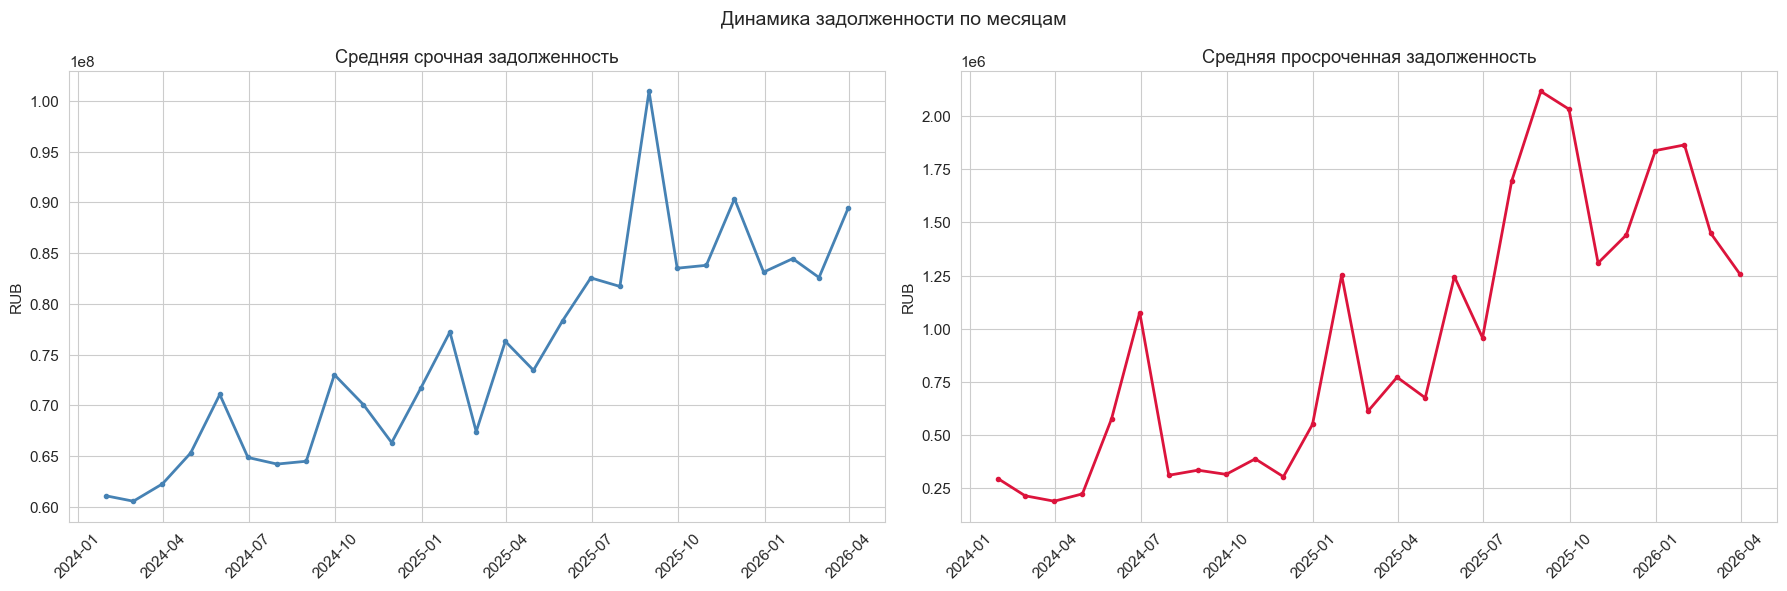

In [12]:
# ─── Динамика задолженности по snapshot_date ───
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Средняя задолженность по месяцам
agg_debt = df.groupby('snapshot_date')['debt_due_rub'].mean()
axes[0].plot(agg_debt.index, agg_debt.values, color='steelblue', linewidth=2, marker='o', markersize=3)
axes[0].set_title('Средняя срочная задолженность')
axes[0].set_ylabel('RUB')
axes[0].tick_params(axis='x', rotation=45)

# Средняя просрочка по месяцам
agg_ovr = df.groupby('snapshot_date')['debt_ovr_rub'].mean()
axes[1].plot(agg_ovr.index, agg_ovr.values, color='crimson', linewidth=2, marker='o', markersize=3)
axes[1].set_title('Средняя просроченная задолженность')
axes[1].set_ylabel('RUB')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Динамика задолженности по месяцам', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Feature Engineering — фрод-признаки

Создаём агрегированные и производные признаки на уровне компании (INN), используя всю историю snapshot'ов:

In [13]:
# ─── Агрегация временных рядов на уровне INN ───
df_sorted = df.sort_values(['inn', 'snapshot_date'])

# Маппинг problem_group → порядковый номер (чем хуже, тем выше)
PROBLEM_GROUP_ORDINAL = {
    'Green Zone': 0, 'Без признаков': 0,
    'Watchlist': 1, 'Под наблюдением': 1,
    'Yellow Zone': 2, 'Потенциально проблемные': 2,
    'Red Zone': 3, 'Проблемные': 3,
    'Black Zone': 4, 'Безнадёжные': 4,
}

def agg_company(group):
    """Агрегация метрик компании по всем snapshot'ам."""
    last = group.iloc[-1]
    first = group.iloc[0]
    n = len(group)
    res = {}

    # Базовые атрибуты (из последнего snapshot)
    for col in ['org_id','inn','okved_cd','okved_name','okved_section','terbank',
                'org_sector','liquidation','risk_segment','segment_name','reg_region',
                'gsz_name','frd_terbank_reg_match','frd_jump_score','max_growth_pct',
                'jump_year','prev_revenue','jump_revenue','max_growth_rub',
                'frd_scheme_code','frd_susp_flag','frd_stg_name',
                'frd_okved_section_diff_benef_0','frd_okved_section_diff_benef_1',
                'frd_okved_cd_diff_benef_0','frd_okved_cd_diff_benef_1',
                'frd_liquidation_ben_0','liquidation_ben_1',
                'doc_number','signed_dt','expiration_dt','issue_dt',
                'grntee_prod_name','problem_group']:
        if col in group.columns:
            res[col] = last[col]

    # ─── Бенефициары: бинарные флаги наличия (вместо raw ID) ───
    for ben_col in ['ben_0', 'ben_1', 'ben_3', 'ben_5']:
        if ben_col in group.columns:
            res[f'has_{ben_col}'] = 1 if pd.notna(last[ben_col]) else 0
        else:
            res[f'has_{ben_col}'] = 0

    # ─── problem_group → ordinal encoding ───
    pg = last.get('problem_group') if 'problem_group' in group.columns else None
    res['problem_group_ordinal'] = PROBLEM_GROUP_ORDINAL.get(pg, -1) if pd.notna(pg) else -1

    # ─── Финансовые агрегаты ───
    res['debt_due_rub_last'] = last.get('debt_due_rub')
    res['debt_due_rub_mean'] = group['debt_due_rub'].mean()
    res['debt_due_rub_max']  = group['debt_due_rub'].max()
    res['debt_due_rub_std']  = group['debt_due_rub'].std()

    res['debt_ovr_rub_last'] = last.get('debt_ovr_rub')
    res['debt_ovr_rub_mean'] = group['debt_ovr_rub'].mean()
    res['debt_ovr_rub_max']  = group['debt_ovr_rub'].max()
    res['debt_ovr_rub_sum']  = group['debt_ovr_rub'].sum()

    res['exposure_amt_last'] = last.get('exposure_amt')
    res['limit_amt'] = last.get('limit_amt')

    res['expo_calc_last']         = last.get('expo_calc')
    res['reserv_prud_calc_last']  = last.get('reserv_prud_calc')
    res['reserv_ocen_calc_last']  = last.get('reserv_ocen_calc')

    # ─── Динамические признаки ───
    debt_first = first.get('debt_due_rub')
    debt_last  = last.get('debt_due_rub')
    if pd.notna(debt_first) and debt_first > 0 and pd.notna(debt_last):
        res['debt_growth_ratio'] = debt_last / debt_first
    else:
        res['debt_growth_ratio'] = None

    # Тренд просрочки
    ovr_series = group['debt_ovr_rub'].fillna(0)
    res['months_with_overdue'] = (ovr_series > 0).sum()
    res['overdue_month_ratio'] = res['months_with_overdue'] / n

    # Волатильность задолженности (коэф. вариации)
    mean_debt = group['debt_due_rub'].mean()
    std_debt  = group['debt_due_rub'].std()
    res['debt_cv'] = std_debt / mean_debt if pd.notna(mean_debt) and mean_debt > 0 else None

    # Максимальная просрочка к лимиту
    ovr_max = group['debt_ovr_rub'].max()
    lim = last.get('limit_amt')
    res['max_ovr_to_limit'] = ovr_max / lim if pd.notna(ovr_max) and pd.notna(lim) and lim > 0 else None

    # Резервы к exposure
    rp = last.get('reserv_prud_calc')
    ec = last.get('expo_calc')
    res['reserv_to_expo_ratio'] = rp / ec if pd.notna(rp) and pd.notna(ec) and ec > 0 else None

    # ─── Новые временные признаки ───

    # Доля snapshot'ов с заполненными финансовыми данными (полнота данных по компании)
    fin_cols_check = ['debt_due_rub','exposure_amt','expo_calc']
    avail_counts = sum(group[c].notna().sum() for c in fin_cols_check if c in group.columns)
    res['fin_data_fill_ratio'] = avail_counts / (n * len(fin_cols_check))

    # Тренд задолженности: линейный slope по snapshot'ам (нормализованный)
    debt_vals = group['debt_due_rub'].dropna()
    if len(debt_vals) >= 3:
        x_idx = np.arange(len(debt_vals), dtype=float)
        y_vals = debt_vals.values.astype(float)
        mean_y = np.nanmean(y_vals)
        if mean_y > 0:
            slope = np.polyfit(x_idx, y_vals, 1)[0]
            res['debt_trend_slope'] = slope / mean_y  # нормализованный slope
        else:
            res['debt_trend_slope'] = None
    else:
        res['debt_trend_slope'] = None

    # Тренд просрочки: нарастает ли
    ovr_vals = group['debt_ovr_rub'].dropna()
    if len(ovr_vals) >= 3:
        first_half = ovr_vals.iloc[:len(ovr_vals)//2].mean()
        second_half = ovr_vals.iloc[len(ovr_vals)//2:].mean()
        res['overdue_trend'] = (second_half - first_half) / max(first_half, 1)
    else:
        res['overdue_trend'] = None

    # Количество snapshot'ов с ненулевой задолженностью
    res['snapshots_with_debt'] = (group['debt_due_rub'].fillna(0) > 0).sum()
    res['debt_presence_ratio'] = res['snapshots_with_debt'] / n

    # ─── Фрод-флаги ───
    res['frd_segment_changed_1y'] = last.get('frd_segment_changed_1y')
    res['frd_segment_changed_2y'] = last.get('frd_segment_changed_2y')
    res['frd_reject_diff_segment_2y'] = last.get('frd_reject_diff_segment_2y')
    res['frd_ben_0_changed'] = last.get('frd_ben_0_changed')
    res['frd_owner_changed_1y'] = last.get('frd_owner_changed_1y')

    # Сколько фрод-флагов сработало (из бинарных)
    flag_sum = 0
    for fc in ['frd_segment_changed_1y','frd_segment_changed_2y',
               'frd_reject_diff_segment_2y','frd_ben_0_changed','frd_owner_changed_1y']:
        v = last.get(fc)
        if pd.notna(v) and v == 1:
            flag_sum += 1
    res['frd_flag_count'] = flag_sum

    # Реструктуризации
    res['restruct_cnt_last'] = last.get('restruct_cnt')
    res['restruct_cnt_max']  = group['restruct_cnt'].max()
    res['had_restruct'] = 1 if group['last_restruct_dt'].notna().any() else 0

    # Просрочки
    res['ovr_cnt_last'] = last.get('ovr_cnt')
    res['ovr_cnt_max']  = group['ovr_cnt'].max()

    # Дефолты
    res['had_default']    = 1 if group['default_start_dt'].notna().any() else 0
    res['in_default_now'] = 1 if pd.notna(last.get('default_start_dt')) and pd.isna(last.get('default_end_dt')) else 0

    # Суды
    res['claim_sum_max']     = group['claim_sum'].max()
    res['claim_count_total'] = group['claim_count'].sum()
    res['had_claims']        = 1 if group['claim_sum'].notna().any() else 0

    # Фрод-реестр
    res['was_in_frd_registry'] = 1 if group['frd_rgstr_sid'].notna().any() else 0
    res['frd_confirmed']       = 1 if (group['frdsgn_stts_code'] == 'CONFIRMED').any() else 0

    # Overdue OD
    res['overdue_od_last'] = last.get('overdue_od_calc')
    res['overdue_od_max']  = group['overdue_od_calc'].max()

    return pd.Series(res)

df_company = df_sorted.groupby('inn').apply(agg_company).reset_index(drop=True)

print(f"Агрегированный датасет: {df_company.shape[0]} компаний × {df_company.shape[1]} признаков")
df_company.head(3)

Агрегированный датасет: 120 компаний × 83 признаков


,org_id,inn,okved_cd,okved_name,okved_section,terbank,org_sector,liquidation,risk_segment,segment_name,reg_region,gsz_name,frd_terbank_reg_match,frd_jump_score,max_growth_pct,jump_year,prev_revenue,jump_revenue,max_growth_rub,frd_scheme_code,frd_susp_flag,frd_stg_name,frd_okved_section_diff_benef_0,frd_okved_section_diff_benef_1,frd_okved_cd_diff_benef_0,frd_okved_cd_diff_benef_1,frd_liquidation_ben_0,liquidation_ben_1,doc_number,signed_dt,expiration_dt,issue_dt,grntee_prod_name,problem_group,has_ben_0,has_ben_1,has_ben_3,has_ben_5,problem_group_ordinal,debt_due_rub_last,debt_due_rub_mean,debt_due_rub_max,debt_due_rub_std,debt_ovr_rub_last,debt_ovr_rub_mean,debt_ovr_rub_max,debt_ovr_rub_sum,exposure_amt_last,limit_amt,expo_calc_last,reserv_prud_calc_last,reserv_ocen_calc_last,debt_growth_ratio,months_with_overdue,overdue_month_ratio,debt_cv,max_ovr_to_limit,reserv_to_expo_ratio,fin_data_fill_ratio,debt_trend_slope,overdue_trend,snapshots_with_debt,debt_presence_ratio,frd_segment_changed_1y,frd_segment_changed_2y,frd_reject_diff_segment_2y,frd_ben_0_changed,frd_owner_changed_1y,frd_flag_count,restruct_cnt_last,restruct_cnt_max,had_restruct,ovr_cnt_last,ovr_cnt_max,had_default,in_default_now,claim_sum_max,claim_count_total,had_claims,was_in_frd_registry,frd_confirmed,overdue_od_last,overdue_od_max
0,100030,1067157848,I69.30,Гостиницы,I,Байкальский,Нефтегаз,Действующее,Средний,Микробизнес,Москва,ГСЗ_35,1,NaN,NaN,NaN,3317478878.51,NaN,NaN,NaN,0,NaN,1,1,1,1,Действующее,Действующее,КД-461603,2021-05-17,2024-11-23,2021-06-14,Проектное финансирование,Без признаков,1,1,1,1,0,NaN,18903860.20,26027641.54,3237256.87,0.00,3211.89,86720.96,86720.96,17524319.26,19674455.94,20065373.30,NaN,661723.54,NaN,1,0.04,0.17,0.00,NaN,0.95,0.02,-1.00,24,0.89,0,0,0,0,0,0,0,1,0,0,1,0,0,3491589.04,4.00,1,0,0,1207214.60,5638264.21
1,100013,1068574553,G19.46,Торговля,G,Московский,IT,Действующее,Низкий,Крупный бизнес,Краснодарский край,ГСЗ_12,1,NaN,NaN,NaN,4966870666.72,NaN,NaN,NaN,0,NaN,1,0,1,0,Действующее,NaN,КД-503837,2020-05-12,2026-07-17,2020-05-22,Гарантия,Без признаков,1,1,1,1,0,4066586.42,3375146.72,4202404.68,546851.49,0.00,11334.64,93300.15,306035.23,6370359.91,8030531.25,3655295.65,409082.29,163515.52,1.44,4,0.15,0.16,0.01,0.11,0.93,0.02,-0.03,25,0.93,0,0,0,0,0,0,0,1,1,0,1,0,0,4692302.64,4.00,1,0,0,300410.31,1013001.02
2,100095,1077633091,E32.79,Водоснабжение,E,Байкальский,Металлургия,Действующее,Средний,Малый бизнес,Санкт-Петербург,ГСЗ_5,1,NaN,NaN,NaN,1837570909.21,NaN,NaN,NaN,0,NaN,0,0,0,0,NaN,NaN,КД-743155,2023-02-04,2029-07-23,2023-02-06,Овердрафт,Без признаков,1,1,1,1,0,NaN,277139577.79,341178845.96,39429496.11,0.00,1151798.17,8727775.29,31098550.51,193654424.70,270265847.95,NaN,41193414.57,11603241.87,NaN,6,0.22,0.14,0.03,NaN,0.96,0.01,0.85,25,0.93,0,0,0,0,0,0,1,1,1,1,1,0,0,3918589.67,9.00,1,0,0,69057658.99,69222071.64


In [14]:
# ─── 4.2 Дополнительные фрод-признаки (v3) ───

# 1. Data completeness score — компании с аномально неполными данными
key_fields = ['debt_due_rub_last', 'exposure_amt_last', 'limit_amt',
              'expo_calc_last', 'risk_segment', 'claim_sum_max',
              'frd_jump_score', 'has_ben_0', 'problem_group']
df_company['data_completeness'] = df_company[key_fields].notna().sum(axis=1) / len(key_fields)

# 2. Log-трансформации финансовых признаков (для адекватного ML на разреженных данных)
log_cols = ['debt_due_rub_last','debt_due_rub_max','debt_ovr_rub_max','debt_ovr_rub_sum',
            'exposure_amt_last','limit_amt','expo_calc_last',
            'reserv_prud_calc_last','reserv_ocen_calc_last','claim_sum_max',
            'overdue_od_max']
for col in log_cols:
    if col in df_company.columns:
        df_company[f'log_{col}'] = np.log1p(df_company[col].clip(lower=0).fillna(0))

# 3. Exposure vs Debt mismatch — exposure >> 0 при отсутствии долга
debt_v = df_company['debt_due_rub_last'].fillna(0)
expo_v = df_company['expo_calc_last'].fillna(0)
df_company['expo_debt_mismatch'] = ((expo_v > 1e6) & (debt_v == 0)).astype(int)

# 4. Reserv/Expo anomaly — резервы > 50% от exposure (повышенный риск)
reserv_v = df_company['reserv_prud_calc_last'].fillna(0)
df_company['reserv_expo_anomaly'] = 0
mask_hi = (expo_v > 0) & (reserv_v / expo_v.replace(0, np.nan) > 0.5)
df_company.loc[mask_hi, 'reserv_expo_anomaly'] = 1

# 5. Beneficiary risk composite — агрегированный риск по бенефициарам
df_company['beneficiary_risk'] = (
    df_company['frd_okved_section_diff_benef_0'].fillna(0).astype(float) * 0.25 +
    df_company['frd_okved_section_diff_benef_1'].fillna(0).astype(float) * 0.15 +
    df_company['frd_ben_0_changed'].fillna(0).astype(float) * 0.35 +
    (df_company['frd_liquidation_ben_0'].isin(['В стадии ликвидации', 'Ликвидировано'])).astype(float) * 0.25
)

# 6. Claims intensity — отношение исков к exposure
df_company['claims_to_expo'] = (
    df_company['claim_sum_max'].fillna(0) /
    df_company['expo_calc_last'].replace(0, np.nan).fillna(1e12)  # avoid div/0
)

# 7. Zero debt anomaly — долг = 0 но есть иски/дефолт, И при этом есть реальные фин. данные
#    v3 fix: добавлено условие fin_data_fill_ratio > 0.1 — исключаем компании без финансовых данных
df_company['zero_debt_anomaly'] = (
    (df_company['debt_due_rub_last'].fillna(0) == 0) &
    ((df_company['had_claims'] == 1) | (df_company['in_default_now'] == 1)) &
    (df_company['fin_data_fill_ratio'] > 0.1)
).astype(int)

# 8. Overdue severity composite
df_company['overdue_severity'] = (
    df_company['overdue_month_ratio'].fillna(0) * 0.4 +
    (df_company['ovr_cnt_max'].fillna(0) > 5).astype(float) * 0.3 +
    df_company['in_default_now'].fillna(0).astype(float) * 0.3
)

# 9. frd_susp_flag (бинарный, из витрины)
df_company['frd_susp_binary'] = df_company['frd_susp_flag'].fillna(0).astype(float).clip(0, 1)

# 10. Debt utilization — долг к лимиту (утилизация)
df_company['debt_to_limit'] = (
    df_company['debt_due_rub_last'].fillna(0) /
    df_company['limit_amt'].replace(0, np.nan).fillna(1e12)
).clip(0, 10)  # cap at 10x

# 11. Overdue to debt ratio — просрочка к общей задолженности
df_company['ovr_to_debt_ratio'] = (
    df_company['debt_ovr_rub_max'].fillna(0) /
    df_company['debt_due_rub_max'].replace(0, np.nan).fillna(1e12)
).clip(0, 10)

# 12. Claims per snapshot — интенсивность судебных исков
n_snapshots = df['snapshot_date'].nunique()
df_company['claims_intensity'] = df_company['claim_count_total'].fillna(0) / n_snapshots

# 13. Multi-method FRD flag (количество одновременных признаков из витрины)
# frd_flag_count уже посчитан в agg_company

# ─── Отчёт по новым признакам ───
n_log = sum(1 for c in df_company.columns if c.startswith('log_'))
print(f"Добавлено: {n_log} log-трансформаций + 12 расчётных признаков")
print(f"Итого признаков df_company: {df_company.shape[1]}")

new_binary = ['expo_debt_mismatch', 'reserv_expo_anomaly', 'zero_debt_anomaly', 'frd_susp_binary']
print(f"\nНовые бинарные признаки (доля = 1):")
for col in new_binary:
    pct = df_company[col].sum() / len(df_company) * 100
    print(f"  {col}: {df_company[col].sum():,.0f} ({pct:.2f}%)")

print(f"\ndata_completeness: mean={df_company['data_completeness'].mean():.3f}, "
      f"min={df_company['data_completeness'].min():.3f}")
print(f"frd_flag_count: mean={df_company['frd_flag_count'].mean():.2f}, "
      f"max={df_company['frd_flag_count'].max():.0f}")
print(f"beneficiary_risk: mean={df_company['beneficiary_risk'].mean():.3f}")
print(f"overdue_severity: mean={df_company['overdue_severity'].mean():.3f}")
print(f"fin_data_fill_ratio: mean={df_company['fin_data_fill_ratio'].mean():.3f}")
print(f"problem_group_ordinal: distribution:")
print(df_company['problem_group_ordinal'].value_counts().sort_index())

Добавлено: 11 log-трансформаций + 12 расчётных признаков
Итого признаков df_company: 105

Новые бинарные признаки (доля = 1):
  expo_debt_mismatch: 7 (5.83%)
  reserv_expo_anomaly: 0 (0.00%)
  zero_debt_anomaly: 9 (7.50%)
  frd_susp_binary: 10 (8.33%)

data_completeness: mean=0.909, min=0.667
frd_flag_count: mean=0.82, max=5
beneficiary_risk: mean=0.320
overdue_severity: mean=0.135
fin_data_fill_ratio: mean=0.957
problem_group_ordinal: distribution:
problem_group_ordinal
0    83
2    22
3    10
4     5
Name: count, dtype: int64


## 4. Rule-based детекция (эвристические правила)

Набор бизнес-правил для выявления подозрительных компаний на основе экспертных знаний антифрод-аналитиков:

Распределение rule_score:
count   120.00
mean     22.83
std      33.31
min       0.00
25%       3.00
50%       9.50
75%      21.00
max     100.00
Name: rule_score, dtype: float64

Компании с rule_score >= 40: 18
Компании с rule_score >= 25: 24
Компании с rule_score > 0:   118

Топ-15 срабатываний правил:
  R7:OKVED_DIFF_BEN0: 89 (74.2%)
  R7:OKVED_DIFF_BEN1: 57 (47.5%)
  R15:PROBLEM_GROUP: 37 (30.8%)
  R3:SEGMENT_CHANGED_2Y: 28 (23.3%)
  R2:TB_REG_MISMATCH: 28 (23.3%)
  R6:OWNER_CHANGED_1Y: 22 (18.3%)
  R14:HIGH_RISK_SEGMENT: 19 (15.8%)
  R5:BENEFICIARY_CHANGED: 18 (15.0%)
  R1:REVENUE_JUMP: 18 (15.0%)
  R10:RESTRUCT_CNT: 18 (15.0%)
  R12:HIGH_CLAIMS: 18 (15.0%)
  R13:FRD_REGISTRY: 18 (15.0%)
  R13:FRD_CONFIRMED: 18 (15.0%)
  R3:SEGMENT_CHANGED_1Y: 17 (14.2%)
  R4:REJECT_DIFF_SEGMENT: 14 (11.7%)


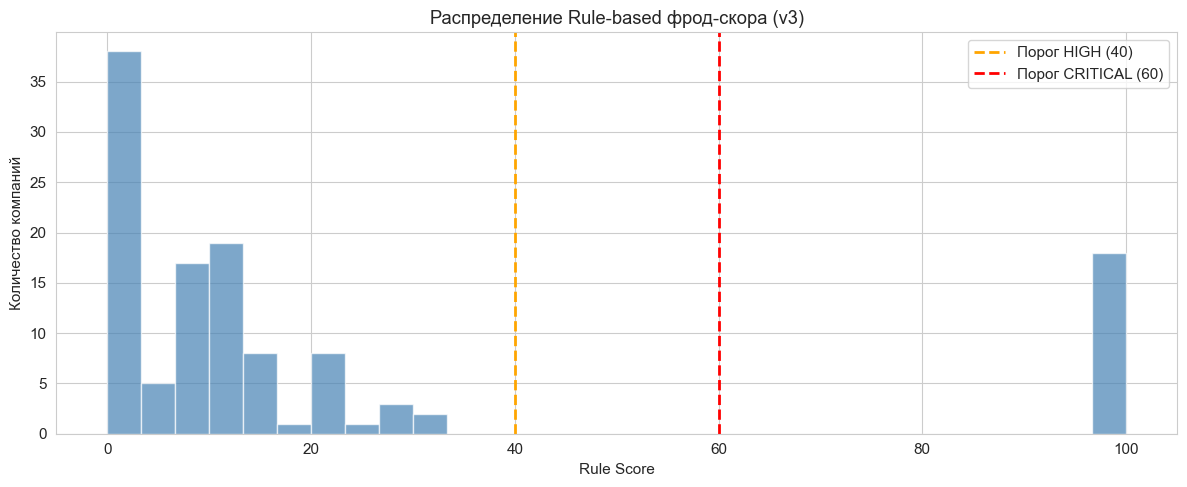

In [15]:
# ─── Rule-based фрод-скоринг (v3, калиброван на реальных данных) ───
#
# Ключевые поправки vs v2:
#   - R15 (problem_group): поддержка англоязычных зон (Red/Yellow/Black Zone) + русских
#   - R19 (zero_debt_anomaly): upstream fix — теперь требует fin_data_fill_ratio > 0.1
#   - R21 (overdue_trend): УДАЛЁН — бесполезен (0.2% nonzero на реальных данных)
#   - R5: оставлен +5 — ~31% сработок, но в комбинации ценен

def apply_fraud_rules_v3(row):
    """Применяем набор эвристических правил. Возвращаем скор (0-100) и список сработавших правил."""
    score = 0
    reasons = []

    # R1: Взрывной рост выручки (frd_jump_score > 0.5 = подозрительно)
    js = row.get('frd_jump_score')
    if pd.notna(js) and js > 0.5:
        score += 15
        reasons.append(f'R1:REVENUE_JUMP>{js:.0%}')

    # R2: Регион ТБ не совпадает с регистрацией (frd_terbank_reg_match == 0, ~8.7%)
    if row.get('frd_terbank_reg_match') == 0:
        score += 8
        reasons.append('R2:TB_REG_MISMATCH')

    # R3: Смена сегмента за 1-2 года (~13.7% / ~28.8%)
    if row.get('frd_segment_changed_1y') == 1:
        score += 10
        reasons.append('R3:SEGMENT_CHANGED_1Y')
    if row.get('frd_segment_changed_2y') == 1:
        score += 5
        reasons.append('R3:SEGMENT_CHANGED_2Y')

    # R4: Отказ при ином сегменте (~1.0%)
    if row.get('frd_reject_diff_segment_2y') == 1:
        score += 12
        reasons.append('R4:REJECT_DIFF_SEGMENT')

    # R5: Смена бенефициара (~31% — распространённо, поэтому +5 вместо +10)
    if row.get('frd_ben_0_changed') == 1:
        score += 5
        reasons.append('R5:BENEFICIARY_CHANGED')

    # R6: Смена собственника (<0.5% — очень редко, сильный сигнал)
    if row.get('frd_owner_changed_1y') == 1:
        score += 12
        reasons.append('R6:OWNER_CHANGED_1Y')

    # R7: ОКВЭД клиента ≠ ОКВЭД бенефициаров (~74% / ~67% — норма для рынка!)
    # Снижен до +2/+1, т.к. это слишком распространено для сигнала фрода
    okved0 = row.get('frd_okved_section_diff_benef_0')
    okved1 = row.get('frd_okved_section_diff_benef_1')
    if pd.notna(okved0) and okved0 == 1:
        score += 2
        reasons.append('R7:OKVED_DIFF_BEN0')
    if pd.notna(okved1) and okved1 == 1:
        score += 1
        reasons.append('R7:OKVED_DIFF_BEN1')

    # R8: Ликвидация бенефициара
    if row.get('frd_liquidation_ben_0') in ['В стадии ликвидации', 'Ликвидировано']:
        score += 12
        reasons.append('R8:BEN0_LIQUIDATED')
    if row.get('liquidation_ben_1') in ['В стадии ликвидации', 'Ликвидировано']:
        score += 8
        reasons.append('R8:BEN1_LIQUIDATED')

    # R9: Высокий уровень просрочки (доля месяцев с просрочкой > 50%)
    omr = row.get('overdue_month_ratio')
    if pd.notna(omr) and omr > 0.5:
        score += 10
        reasons.append(f'R9:HIGH_OVERDUE_RATIO={omr:.0%}')

    # R10: Множественные реструктуризации (>=2)
    rc = row.get('restruct_cnt_max')
    if pd.notna(rc) and rc >= 2:
        score += 8
        reasons.append(f'R10:RESTRUCT_CNT={int(rc)}')

    # R11: Текущий или исторический дефолт
    if row.get('in_default_now') == 1:
        score += 15
        reasons.append('R11:IN_DEFAULT_NOW')
    elif row.get('had_default') == 1:
        score += 7
        reasons.append('R11:HAD_DEFAULT')

    # R12: Крупные судебные иски (>10M руб)
    cs = row.get('claim_sum_max')
    if pd.notna(cs) and cs > 1e7:
        score += 8
        reasons.append(f'R12:HIGH_CLAIMS={cs/1e6:.0f}M')

    # R13: Фрод-реестр
    if row.get('was_in_frd_registry') == 1:
        score += 15
        reasons.append('R13:FRD_REGISTRY')
    if row.get('frd_confirmed') == 1:
        score += 10
        reasons.append('R13:FRD_CONFIRMED')

    # R14: Высокий риск-сегмент
    if row.get('risk_segment') == 'Высокий':
        score += 8
        reasons.append('R14:HIGH_RISK_SEGMENT')

    # R15: Проблемная группа (поддержка и русских и английских названий)
    pg = row.get('problem_group')
    if pg in ['Проблемные', 'Red Zone']:
        score += 8
        reasons.append(f'R15:PROBLEM_GROUP={pg}')
    elif pg in ['Безнадёжные', 'Black Zone']:
        score += 12
        reasons.append(f'R15:PROBLEM_GROUP={pg}')
    elif pg in ['Потенциально проблемные', 'Yellow Zone']:
        score += 5
        reasons.append(f'R15:PROBLEM_GROUP={pg}')

    # R16: Высокое отношение резервов к exposure (>30%)
    rte = row.get('reserv_to_expo_ratio')
    if pd.notna(rte) and rte > 0.3:
        score += 6
        reasons.append(f'R16:HIGH_RESERV_RATIO={rte:.1%}')

    # R17: Рост задолженности > 2x
    dg = row.get('debt_growth_ratio')
    if pd.notna(dg) and dg > 2.0:
        score += 10
        reasons.append(f'R17:DEBT_GROWTH={dg:.1f}x')

    # ─── Новые правила v2 ───

    # R18: Множественные одновременные фрод-флаги (>=3 из 5)
    ffc = row.get('frd_flag_count', 0)
    if pd.notna(ffc) and ffc >= 3:
        score += 10
        reasons.append(f'R18:MULTI_FRD_FLAGS={int(ffc)}')

    # R19: Zero debt anomaly — нет долга, но есть иски/дефолт (upstream fix: только при наличии фин. данных)
    if row.get('zero_debt_anomaly') == 1:
        score += 8
        reasons.append('R19:ZERO_DEBT_ANOMALY')

    # R20: Подозрительный по данным витрины (frd_susp_flag)
    if row.get('frd_susp_binary') == 1:
        score += 10
        reasons.append('R20:FRD_SUSP_FLAG')

    # R21: УДАЛЁН — overdue_trend бесполезен (0.2% nonzero на реальных данных, 95% компаний без фин. рядов)

    return min(score, 100), '|'.join(reasons) if reasons else 'CLEAN'

# Применяем правила
df_company[['rule_score', 'rule_reasons']] = df_company.apply(
    lambda r: pd.Series(apply_fraud_rules_v3(r)), axis=1
)

print("Распределение rule_score:")
print(df_company['rule_score'].describe())
print(f"\nКомпании с rule_score >= 40: {(df_company['rule_score'] >= 40).sum()}")
print(f"Компании с rule_score >= 25: {(df_company['rule_score'] >= 25).sum()}")
print(f"Компании с rule_score > 0:   {(df_company['rule_score'] > 0).sum()}")

# Топ-10 самых частых правил
from collections import Counter
all_rules = []
for reasons in df_company['rule_reasons']:
    if reasons != 'CLEAN':
        for r in reasons.split('|'):
            rule_code = r.split(':')[0] + ':' + r.split(':')[1].split('=')[0].split('>')[0] if ':' in r else r
            all_rules.append(rule_code)
rule_freq = Counter(all_rules).most_common(15)
print(f"\nТоп-15 срабатываний правил:")
for rule, cnt in rule_freq:
    pct = cnt / len(df_company) * 100
    print(f"  {rule}: {cnt:,} ({pct:.1f}%)")

# Гистограмма
fig, ax = plt.subplots(figsize=(12, 5))
df_company['rule_score'].hist(bins=30, alpha=0.7, color='steelblue', edgecolor='white', ax=ax)
ax.axvline(x=40, color='orange', linestyle='--', linewidth=2, label='Порог HIGH (40)')
ax.axvline(x=60, color='red', linestyle='--', linewidth=2, label='Порог CRITICAL (60)')
ax.set_xlabel('Rule Score')
ax.set_ylabel('Количество компаний')
ax.set_title('Распределение Rule-based фрод-скора (v3)')
ax.legend()
plt.tight_layout()
plt.show()

## 5. ML-модели для детекции аномалий

### 5.1 Подготовка признаков для ML
### 5.2 Isolation Forest
### 5.3 Local Outlier Factor (LOF)
### 5.4 DBSCAN кластеризация
### 5.5 PCA визуализация

In [16]:
# ─── 5.1 Подготовка признаков для ML (v3) ───
#
# Изменения vs v2:
#   - УДАЛЕНЫ: ben_0..5 (raw IDs) → заменены has_ben_* (бинарные)
#   - УДАЛЕНЫ: ovr_cnt_max (обратная корреляция — чистые=26.7, подозрительные=9.25)
#   - УДАЛЕНЫ: max_ovr_to_limit (0% nonzero), had_restruct (0.1%), overdue_trend (0.2%)
#   - УДАЛЕНЫ: frd_confirmed (0%), debt_trend_slope (4.9%), frd_owner_changed_1y (0.5%)
#   - УДАЛЕНЫ: log_debt_ovr_rub_max, log_debt_ovr_rub_sum, log_overdue_od_max — <1% nonzero
#   - УДАЛЕНЫ: months_with_overdue, overdue_month_ratio (дублируют overdue_severity)
#   - УДАЛЕНЫ: restruct_cnt_max (<1% nonzero)
#   - ДОБАВЛЕНЫ: has_ben_0..has_ben_5 (бинарные флаги наличия бенефициаров)
#   - ДОБАВЛЕН: problem_group_ordinal (ординальное кодирование зоны)

ml_features = [
    # ─── Фрод-флаги из витрины ───
    'frd_terbank_reg_match', 'frd_segment_changed_1y', 'frd_segment_changed_2y',
    'frd_reject_diff_segment_2y', 'frd_ben_0_changed',
    'frd_susp_binary',
    'frd_okved_section_diff_benef_0', 'frd_okved_section_diff_benef_1',
    'frd_okved_cd_diff_benef_0', 'frd_okved_cd_diff_benef_1',
    'frd_jump_score',

    # ─── Финансовые (log-transformed) ───
    'log_debt_due_rub_last', 'log_debt_due_rub_max',
    'log_exposure_amt_last', 'log_limit_amt',
    'log_expo_calc_last',
    'log_reserv_prud_calc_last', 'log_reserv_ocen_calc_last',
    'log_claim_sum_max',

    # ─── Расчётные raw ───
    'debt_due_rub_std',
    'debt_growth_ratio',
    'debt_cv', 'reserv_to_expo_ratio',

    # ─── Бинарные события ───
    'had_default', 'in_default_now', 'had_claims',
    'was_in_frd_registry',

    # ─── Бенефициары (бинарные флаги наличия) ───
    'has_ben_0', 'has_ben_1', 'has_ben_3', 'has_ben_5',

    # ─── Новые v3 признаки ───
    'problem_group_ordinal',
    'data_completeness', 'fin_data_fill_ratio',
    'expo_debt_mismatch', 'reserv_expo_anomaly',
    'beneficiary_risk', 'claims_to_expo',
    'zero_debt_anomaly', 'overdue_severity',
    'debt_to_limit', 'ovr_to_debt_ratio',
    'claims_intensity', 'frd_flag_count',
    'debt_presence_ratio',
]

# Оставляем только те признаки, что реально есть в данных
ml_features = [f for f in ml_features if f in df_company.columns]

# Подготовка числовой матрицы
X = df_company[ml_features].copy()
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Замена inf на NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Заполнение пропусков медианой
X = X.fillna(X.median())

# Если после median fill остались NaN (столбец полностью null) -> заполняем 0
X = X.fillna(0)

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=ml_features)

print(f"ML матрица: {X_scaled_df.shape}")
print(f"Признаков: {len(ml_features)}")
print(f"Пропуски после заполнения: {np.isnan(X_scaled).sum()}")
print(f"Inf значения: {np.isinf(X_scaled).sum()}")

# Процент ненулевых значений по фичам (для оценки полезности)
nonzero_pct = (X != 0).sum() / len(X) * 100
low_info = nonzero_pct[nonzero_pct < 5].sort_values()
if len(low_info) > 0:
    print(f"\nПризнаки с <5% ненулевых значений (возможно низкая информативность):")
    for feat, pct in low_info.items():
        print(f"  {feat}: {pct:.1f}% ненулевых")

ML матрица: (120, 45)
Признаков: 45
Пропуски после заполнения: 0
Inf значения: 0

Признаки с <5% ненулевых значений (возможно низкая информативность):
  reserv_expo_anomaly: 0.0% ненулевых
  in_default_now: 3.3% ненулевых


In [17]:
# ─── 5.2 Isolation Forest (v2) ───
# contamination снижен: 0.15 → 0.06 (~6% аномалий, ≈14К для 230К компаний)
# Для реальных данных 15% — слишком много, реальных мошенников < 5%

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.06,
    max_samples=min(10000, len(X_scaled)),  # ограничиваем subsample для скорости
    random_state=42,
    n_jobs=-1
)
df_company['iso_score'] = iso_forest.fit_predict(X_scaled)
df_company['iso_anomaly_score'] = -iso_forest.decision_function(X_scaled)

# Нормализуем в 0-100
iso_min, iso_max = df_company['iso_anomaly_score'].min(), df_company['iso_anomaly_score'].max()
df_company['iso_score_norm'] = ((df_company['iso_anomaly_score'] - iso_min) / (iso_max - iso_min) * 100).round(1)

iso_anomalies = df_company[df_company['iso_score'] == -1]
print(f"Isolation Forest: {len(iso_anomalies)} аномалий из {len(df_company)} ({len(iso_anomalies)/len(df_company):.1%})")
print(f"Топ-5 по anomaly score:")
print(iso_anomalies.nlargest(5, 'iso_score_norm')[['inn','org_id','iso_score_norm']].to_string(index=False))

# Пересечение с rule-based
iso_and_rules = df_company[(df_company['iso_score'] == -1) & (df_company['rule_score'] >= 40)]
print(f"\nIsolation Forest ∩ Rule-based(>=40): {len(iso_and_rules)} компаний")
print(f"ISO anomalies со средним rule_score: {iso_anomalies['rule_score'].mean():.1f}")

Isolation Forest: 8 аномалий из 120 (6.7%)
Топ-5 по anomaly score:
       inn  org_id  iso_score_norm
2695186921  100117          100.00
7976547497  100048           98.00
2272485020  100029           94.40
9573844352  100086           93.60
6188069941  100018           89.20

Isolation Forest ∩ Rule-based(>=40): 8 компаний
ISO anomalies со средним rule_score: 100.0


In [18]:
# ─── 5.3 Local Outlier Factor (v2) ───
# n_neighbors увеличен: 20 → 50 (лучше для 230К компаний)
# contamination снижен: 0.15 → 0.06

lof = LocalOutlierFactor(
    n_neighbors=50,
    contamination=0.06,
    metric='euclidean',
    n_jobs=-1
)
df_company['lof_pred'] = lof.fit_predict(X_scaled)
df_company['lof_score'] = -lof.negative_outlier_factor_

# Нормализация 0-100
lof_min, lof_max = df_company['lof_score'].min(), df_company['lof_score'].max()
df_company['lof_score_norm'] = ((df_company['lof_score'] - lof_min) / (lof_max - lof_min) * 100).round(1)

lof_anomalies = df_company[df_company['lof_pred'] == -1]
print(f"LOF: {len(lof_anomalies)} аномалий из {len(df_company)} ({len(lof_anomalies)/len(df_company):.1%})")
print(f"Топ-5 по LOF score:")
print(lof_anomalies.nlargest(5, 'lof_score_norm')[['inn','org_id','lof_score_norm']].to_string(index=False))

# Пересечение LOF и ISO
lof_and_iso = df_company[(df_company['lof_pred'] == -1) & (df_company['iso_score'] == -1)]
print(f"\nLOF ∩ ISO: {len(lof_and_iso)} компаний (общие аномалии)")
print(f"LOF anomalies со средним rule_score: {lof_anomalies['rule_score'].mean():.1f}")

LOF: 8 аномалий из 120 (6.7%)
Топ-5 по LOF score:
       inn  org_id  lof_score_norm
5093412388  100112          100.00
8418576734  100024           68.80
7976547497  100048           68.60
1866377394  100044           67.50
2695186921  100117           66.70

LOF ∩ ISO: 5 компаний (общие аномалии)
LOF anomalies со средним rule_score: 76.2


PCA для DBSCAN: 15 компонент, объяснённая дисперсия: 90.8%


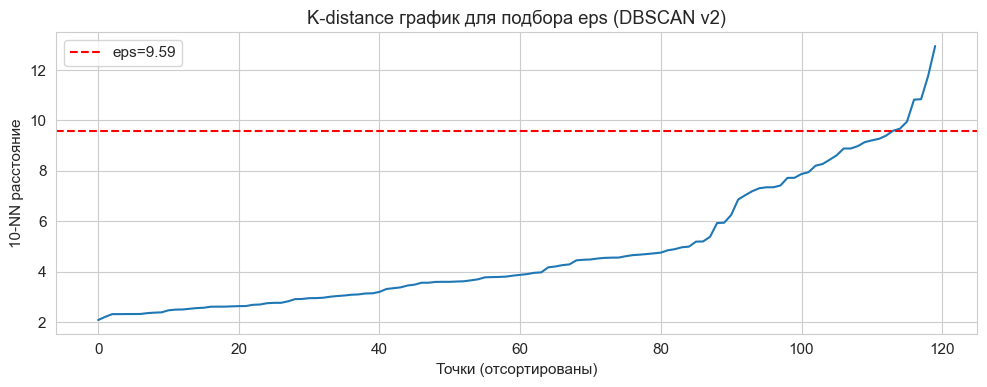


DBSCAN: 2 кластеров (вкл. шум)
Шум (cluster=-1): 1 компаний (0.8%)

Топ кластеров по размеру:
                count  mean_rule_score
dbscan_cluster                        
 0                119            23.00
-1                  1             2.00


In [19]:
# ─── 5.4 DBSCAN кластеризация (v2) ───
# Изменения:
#   - PCA 10→15 компонент (больше признаков)
#   - min_samples=10 (вместо 3 — меньше микро-кластеров для 230К)
#   - eps по 95-му перцентилю (вместо 90-го — агрессивнее группируем)

pca_for_db = PCA(n_components=15, random_state=42)
X_pca_db = pca_for_db.fit_transform(X_scaled)
print(f"PCA для DBSCAN: {X_pca_db.shape[1]} компонент, "
      f"объяснённая дисперсия: {pca_for_db.explained_variance_ratio_.sum():.1%}")

# K-distance для подбора eps
nn = NearestNeighbors(n_neighbors=10)
nn.fit(X_pca_db)
distances, _ = nn.kneighbors(X_pca_db)
k_distances = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_distances)
ax.set_xlabel('Точки (отсортированы)')
ax.set_ylabel('10-NN расстояние')
ax.set_title('K-distance график для подбора eps (DBSCAN v2)')
eps_val = np.percentile(k_distances, 95)
ax.axhline(y=eps_val, color='red', linestyle='--', label=f'eps={eps_val:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

dbscan = DBSCAN(eps=eps_val, min_samples=10)
df_company['dbscan_cluster'] = dbscan.fit_predict(X_pca_db)

n_clusters = df_company['dbscan_cluster'].nunique()
n_noise = (df_company['dbscan_cluster'] == -1).sum()
print(f"\nDBSCAN: {n_clusters} кластеров (вкл. шум)")
print(f"Шум (cluster=-1): {n_noise} компаний ({n_noise/len(df_company):.1%})")

# Статистика кластеров (топ-10 + шум)
cluster_stats = df_company.groupby('dbscan_cluster').agg(
    count=('inn', 'count'),
    mean_rule_score=('rule_score', 'mean')
).round(1)
# Показываем шум + топ-10 крупных кластеров
top_clusters = cluster_stats.sort_values('count', ascending=False).head(11)
print(f"\nТоп кластеров по размеру:")
print(top_clusters.to_string())

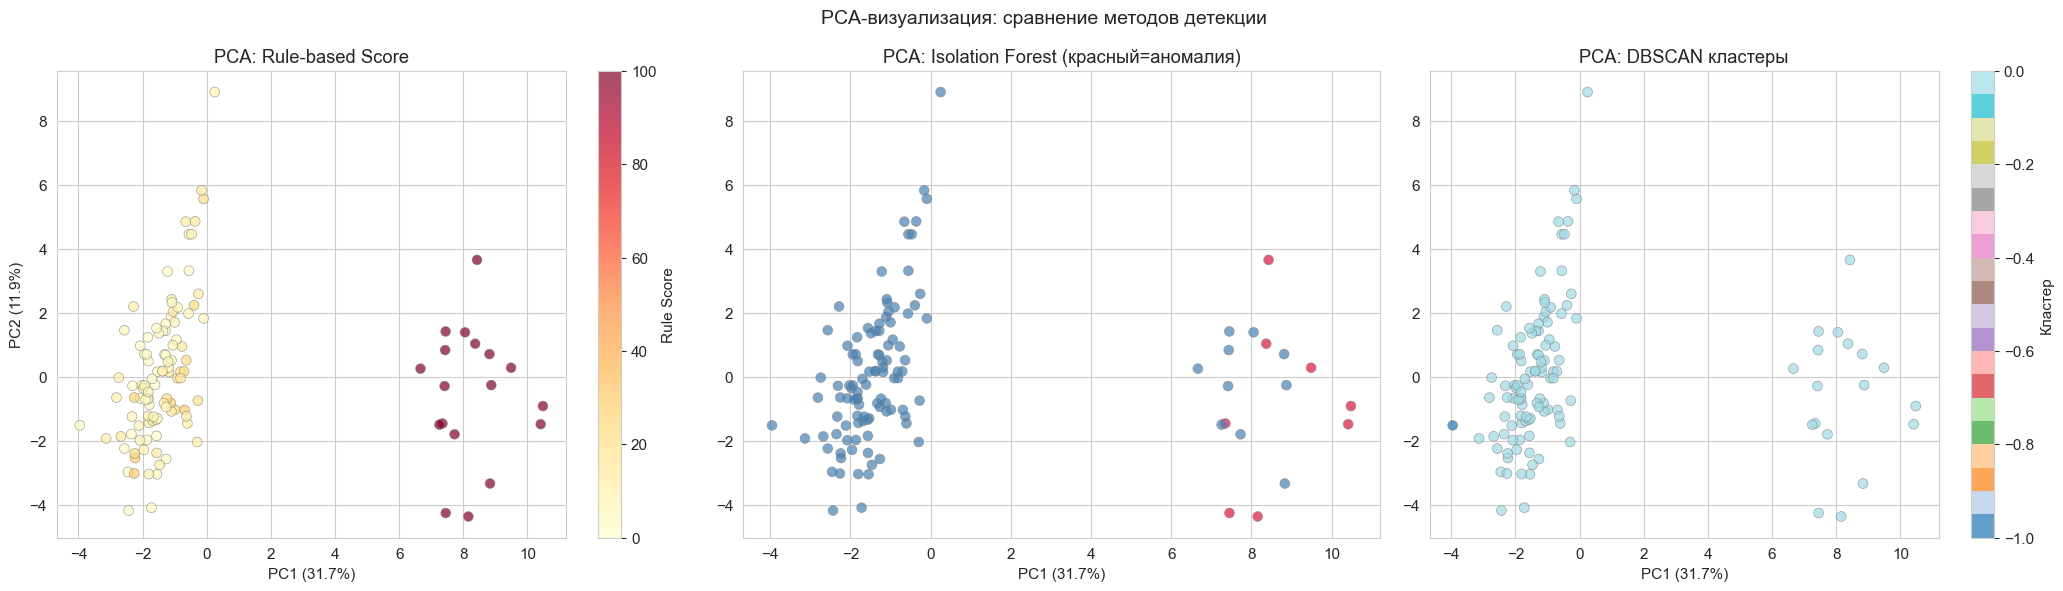


Объяснённая дисперсия PCA (2 компоненты): 43.6%


In [20]:
# ─── 5.5 PCA визуализация ───
pca = PCA(n_components=2, random_state=42)
X_pca2 = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# PCA: Rule-based score
scatter1 = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1],
                           c=df_company['rule_score'], cmap='YlOrRd',
                           alpha=0.7, s=50, edgecolors='grey', linewidths=0.5)
axes[0].set_title('PCA: Rule-based Score')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter1, ax=axes[0], label='Rule Score')

# PCA: Isolation Forest
colors_iso = ['crimson' if x == -1 else 'steelblue' for x in df_company['iso_score']]
axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1], c=colors_iso, alpha=0.7, s=50,
                edgecolors='grey', linewidths=0.5)
axes[1].set_title('PCA: Isolation Forest (красный=аномалия)')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')

# PCA: DBSCAN
scatter3 = axes[2].scatter(X_pca2[:, 0], X_pca2[:, 1],
                           c=df_company['dbscan_cluster'], cmap='tab20',
                           alpha=0.7, s=50, edgecolors='grey', linewidths=0.5)
axes[2].set_title('PCA: DBSCAN кластеры')
axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.colorbar(scatter3, ax=axes[2], label='Кластер')

plt.suptitle('PCA-визуализация: сравнение методов детекции', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nОбъяснённая дисперсия PCA (2 компоненты): {pca.explained_variance_ratio_.sum():.1%}")

## 6. Composite Fraud Score — комбинированный скоринг

Объединяем результаты всех методов в единый скор:
- **Rule-based score** (40%) — экспертные правила
- **Isolation Forest score** (25%) — глобальные аномалии
- **LOF score** (20%) — локальные аномалии
- **DBSCAN noise flag** (15%) — кластерные выбросы

Распределение Composite Score (v3):
count   120.00
mean     21.53
std      24.45
min       0.90
25%       6.17
50%      11.85
75%      21.70
max      81.70
Name: composite_score, dtype: float64

Confidence weighting:
  confidence_weight: mean=1.000, <1.0: 0 компаний
  Скор снижен (confidence<1): 0

Распределение по уровням риска:
  CRITICAL: 18 компаний (15.00%)
  HIGH: 3 компаний (2.50%)
  MEDIUM: 13 компаний (10.83%)
  LOW: 86 компаний (71.67%)


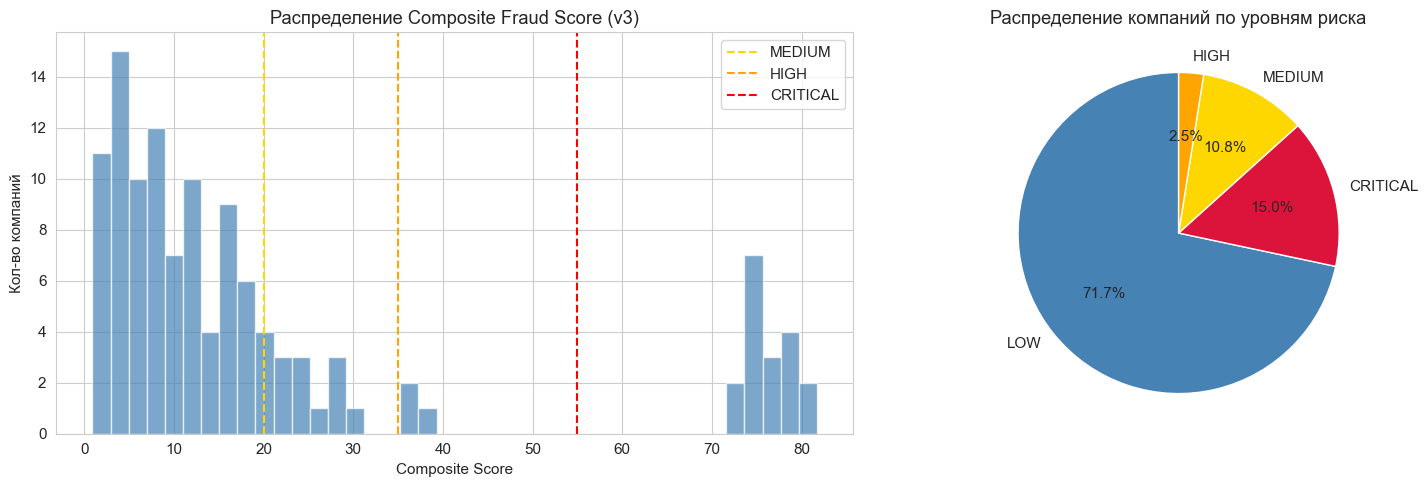

In [21]:
# ─── Composite Score (v3) ───
# Изменения vs v2:
#   - LOF вес снижен 0.20→0.10 (LOF детектит разреженность, а не фрод)
#   - ISO вес повышен 0.25→0.30 (более стабильные результаты)
#   - Добавлено confidence weighting: composite *= min(1, data_completeness / 0.5)
#     Компании с <50% заполненности данных получают пониженный итоговый скор
W_RULES  = 0.45
W_ISO    = 0.30
W_LOF    = 0.10
W_DBSCAN = 0.15

# DBSCAN: шум = 100, иначе 0
df_company['dbscan_noise_score'] = (df_company['dbscan_cluster'] == -1).astype(int) * 100

# Сырой composite (до confidence weighting)
df_company['composite_raw'] = (
    W_RULES  * df_company['rule_score'] +
    W_ISO    * df_company['iso_score_norm'] +
    W_LOF    * df_company['lof_score_norm'] +
    W_DBSCAN * df_company['dbscan_noise_score']
).round(1)

# Confidence weighting: понижаем скор компаний с малой полнотой данных
# data_completeness < 0.5 → линейное снижение, >= 0.5 → полный скор
df_company['confidence_weight'] = (df_company['data_completeness'] / 0.5).clip(upper=1.0)
df_company['composite_score'] = (df_company['composite_raw'] * df_company['confidence_weight']).round(1)

# Категоризация риска
def risk_category(score):
    if score >= 55:
        return 'CRITICAL'
    elif score >= 35:
        return 'HIGH'
    elif score >= 20:
        return 'MEDIUM'
    else:
        return 'LOW'

df_company['risk_level'] = df_company['composite_score'].apply(risk_category)

print("Распределение Composite Score (v3):")
print(df_company['composite_score'].describe())
print(f"\nConfidence weighting:")
print(f"  confidence_weight: mean={df_company['confidence_weight'].mean():.3f}, "
      f"<1.0: {(df_company['confidence_weight'] < 1.0).sum():,} компаний")
print(f"  Скор снижен (confidence<1): {(df_company['composite_raw'] != df_company['composite_score']).sum():,}")

print(f"\nРаспределение по уровням риска:")
risk_dist = df_company['risk_level'].value_counts()
for level in ['CRITICAL','HIGH','MEDIUM','LOW']:
    cnt = risk_dist.get(level, 0)
    pct = cnt / len(df_company) * 100
    print(f"  {level}: {cnt:,} компаний ({pct:.2f}%)")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_company['composite_score'], bins=40, alpha=0.7, color='steelblue', edgecolor='white')
for thresh, color, label in [(20, 'gold', 'MEDIUM'), (35, 'orange', 'HIGH'), (55, 'red', 'CRITICAL')]:
    axes[0].axvline(x=thresh, color=color, linestyle='--', linewidth=1.5, label=label)
axes[0].set_xlabel('Composite Score')
axes[0].set_ylabel('Кол-во компаний')
axes[0].set_title('Распределение Composite Fraud Score (v3)')
axes[0].legend()

risk_counts = df_company['risk_level'].value_counts()
colors_pie = {'CRITICAL': 'crimson', 'HIGH': 'orange', 'MEDIUM': 'gold', 'LOW': 'steelblue'}
axes[1].pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%',
           colors=[colors_pie.get(x, 'grey') for x in risk_counts.index], startangle=90)
axes[1].set_title('Распределение компаний по уровням риска')
plt.tight_layout()
plt.show()

## 7. Feature Importance — важность признаков

Определяем, какие признаки вносят наибольший вклад в выявление аномалий (Isolation Forest).

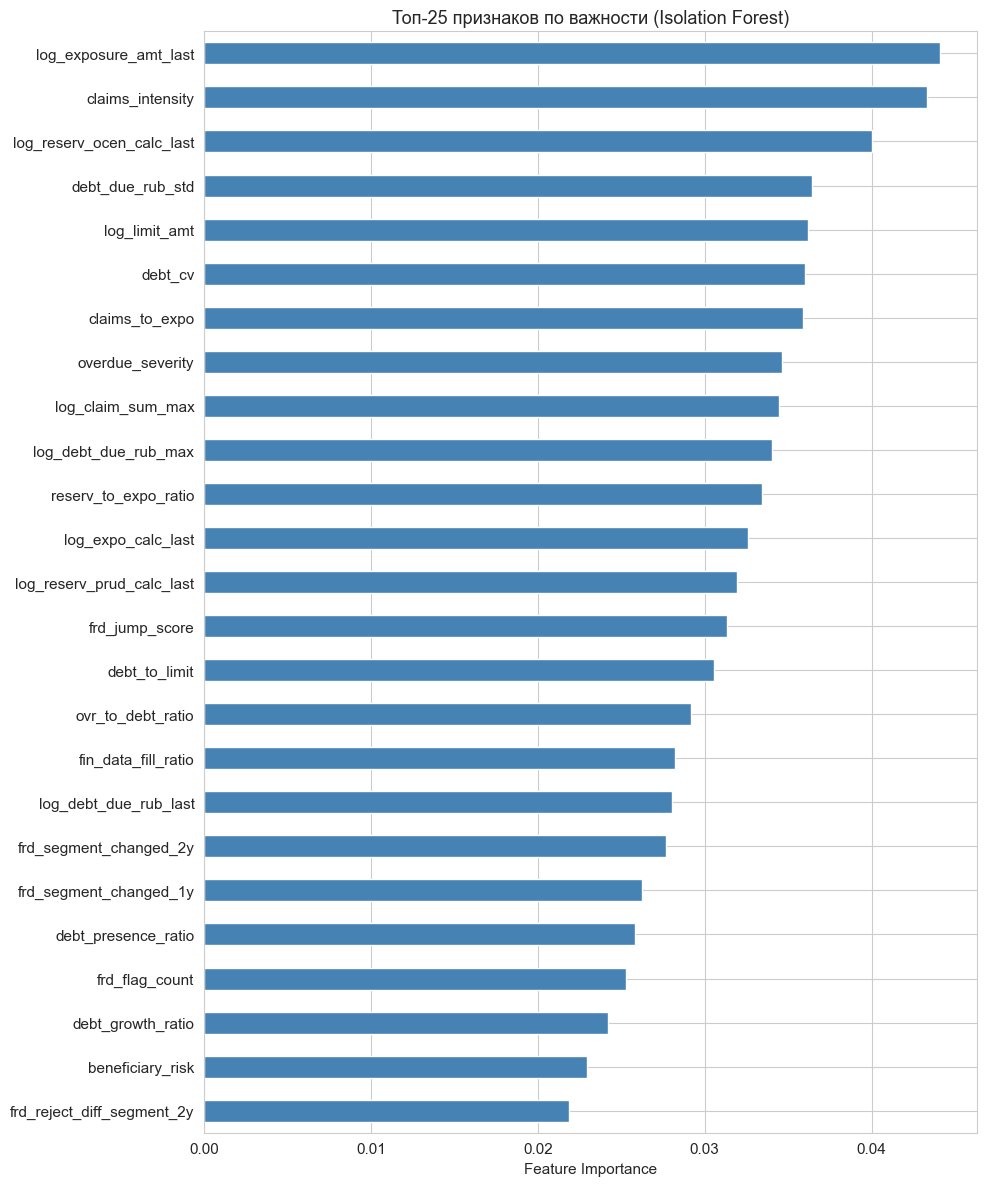

Топ-10 признаков:
  log_debt_due_rub_max: 0.0340
  log_claim_sum_max: 0.0344
  overdue_severity: 0.0346
  claims_to_expo: 0.0359
  debt_cv: 0.0360
  log_limit_amt: 0.0362
  debt_due_rub_std: 0.0364
  log_reserv_ocen_calc_last: 0.0400
  claims_intensity: 0.0433
  log_exposure_amt_last: 0.0441


In [22]:
# ─── Feature Importance (на основе глубины деревьев Isolation Forest) ───
importances = pd.Series(
    iso_forest.feature_importances_ if hasattr(iso_forest, 'feature_importances_') 
    else np.mean([tree.feature_importances_ for tree in iso_forest.estimators_], axis=0),
    index=ml_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
importances.tail(25).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Топ-25 признаков по важности (Isolation Forest)', fontsize=13)
ax.set_xlabel('Feature Importance')
plt.tight_layout()
plt.show()

print("Топ-10 признаков:")
for feat, imp in importances.tail(10).items():
    print(f"  {feat}: {imp:.4f}")

## 8. Итоговый список подозрительных компаний

Финальная таблица с компаниями, отсортированными по composite fraud score, с техническим обоснованием фрода.

In [23]:
# ─── Формирование причин по ML-моделям ───
def build_ml_reasons(row):
    """Формирует техническое обоснование на основе ML-моделей."""
    parts = []
    if row['iso_score'] == -1:
        parts.append(f"ISO_FOREST_ANOMALY(score={row['iso_score_norm']:.0f})")
    if row['lof_pred'] == -1:
        parts.append(f"LOF_ANOMALY(score={row['lof_score_norm']:.0f})")
    if row['dbscan_cluster'] == -1:
        parts.append('DBSCAN_NOISE')
    return '|'.join(parts) if parts else ''

df_company['ml_reasons'] = df_company.apply(build_ml_reasons, axis=1)

# Объединяем все причины
df_company['all_reasons'] = df_company.apply(
    lambda r: '|'.join(filter(None, [r['rule_reasons'] if r['rule_reasons'] != 'CLEAN' else '',
                                      r['ml_reasons']])),
    axis=1
)

# ─── Итоговая таблица ───
suspicious = df_company[df_company['risk_level'].isin(['CRITICAL', 'HIGH', 'MEDIUM'])].sort_values(
    'composite_score', ascending=False
)

result_cols = [
    'inn', 'org_id', 'okved_section', 'org_sector', 'segment_name', 'reg_region',
    'terbank', 'risk_segment', 'liquidation', 'problem_group',
    'composite_score', 'confidence_weight', 'risk_level', 'rule_score',
    'iso_score_norm', 'lof_score_norm', 'dbscan_cluster',
    'debt_due_rub_last', 'debt_ovr_rub_max', 'exposure_amt_last',
    'restruct_cnt_max', 'ovr_cnt_max', 'had_default', 'in_default_now',
    'frd_jump_score', 'max_growth_pct',
    'had_claims', 'claim_sum_max', 'was_in_frd_registry',
    'all_reasons'
]

result_table = suspicious[result_cols].reset_index(drop=True)
result_table.index = result_table.index + 1
result_table.index.name = '#'

print(f"={'='*80}")
print(f"  ПОДОЗРИТЕЛЬНЫЕ КОМПАНИИ: {len(result_table)} из {len(df_company)}")
print(f"  CRITICAL: {(result_table['risk_level']=='CRITICAL').sum()}")
print(f"  HIGH: {(result_table['risk_level']=='HIGH').sum()}")
print(f"  MEDIUM: {(result_table['risk_level']=='MEDIUM').sum()}")
print(f"={'='*80}")

result_table

  ПОДОЗРИТЕЛЬНЫЕ КОМПАНИИ: 34 из 120
  CRITICAL: 18
  HIGH: 3
  MEDIUM: 13


,inn,org_id,okved_section,org_sector,segment_name,reg_region,terbank,risk_segment,liquidation,problem_group,composite_score,confidence_weight,risk_level,rule_score,iso_score_norm,lof_score_norm,dbscan_cluster,debt_due_rub_last,debt_ovr_rub_max,exposure_amt_last,restruct_cnt_max,ovr_cnt_max,had_default,in_default_now,frd_jump_score,max_growth_pct,had_claims,claim_sum_max,was_in_frd_registry,all_reasons
#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,2695186921,100117,D,АПК,Средний бизнес,Приморский край,Северо-Западный,Повышенный,Действующее,Потенциально проблемные,81.70,1.00,CRITICAL,100,100.00,66.70,0,20819560.65,29474433.87,7881741.93,4,11,1,1,0.99,1496.26,1,459439958.71,1,R1:REVENUE_JUMP>99%|R3:SEGMENT_CHANGED_1Y|R3:S...
2,7976547497,100048,O,IT,Микробизнес,Иркутская обл.,Северо-Западный,Высокий,Действующее,Без признаков,81.30,1.00,CRITICAL,100,98.00,68.60,0,105358268.58,72481879.08,80917317.37,4,11,1,1,0.77,1207.73,1,433423211.97,1,R1:REVENUE_JUMP>77%|R2:TB_REG_MISMATCH|R3:SEGM...
3,9573844352,100086,S,Фармацевтика,Крупный бизнес,Краснодарский край,Юго-Западный,Повышенный,Ликвидировано,Проблемные,79.60,1.00,CRITICAL,100,93.60,65.50,0,9153795.62,11542509.71,6639327.59,4,11,1,1,0.68,1272.97,1,489506116.89,1,R1:REVENUE_JUMP>68%|R2:TB_REG_MISMATCH|R3:SEGM...
4,2272485020,100029,E,Финансы,Микробизнес,Приморский край,Московский,Повышенный,В стадии ликвидации,Безнадёжные,79.30,1.00,CRITICAL,100,94.40,59.90,0,62881896.99,105613533.89,36849258.39,4,11,1,0,0.72,1528.89,1,491843015.40,1,R1:REVENUE_JUMP>72%|R2:TB_REG_MISMATCH|R3:SEGM...
5,8418576734,100024,E,Нефтегаз,Микробизнес,Воронежская обл.,Сибирский,Повышенный,Действующее,Потенциально проблемные,77.90,1.00,CRITICAL,100,86.90,68.80,0,2206116.68,748303.53,1832673.49,4,11,1,0,0.94,1567.08,1,491326259.13,1,R1:REVENUE_JUMP>94%|R3:SEGMENT_CHANGED_1Y|R3:S...
6,6188069941,100018,I,Транспорт,Малый бизнес,Тюменская обл.,Северо-Западный,Высокий,Действующее,Безнадёжные,77.70,1.00,CRITICAL,100,89.20,59.50,0,5432579.18,4324310.63,2280485.04,4,11,1,0,0.93,1181.62,1,486610062.37,1,R1:REVENUE_JUMP>93%|R3:SEGMENT_CHANGED_1Y|R7:O...
7,4929721883,100034,R,Транспорт,Средний бизнес,Свердловская обл.,Северо-Западный,Высокий,Действующее,Потенциально проблемные,76.70,1.00,CRITICAL,100,87.00,56.30,0,53572162.66,95445345.59,27345240.15,4,10,1,0,0.74,1255.80,1,484159052.79,1,R1:REVENUE_JUMP>74%|R2:TB_REG_MISMATCH|R3:SEGM...
8,3724518272,100073,P,Транспорт,Малый бизнес,Приморский край,Дальневосточный,Повышенный,Ликвидировано,Без признаков,76.60,1.00,CRITICAL,100,86.90,55.50,0,9978953.57,6140049.90,14247642.83,4,11,1,0,0.71,1358.97,1,476347843.52,1,R1:REVENUE_JUMP>71%|R2:TB_REG_MISMATCH|R3:SEGM...
9,1897955761,100082,F,АПК,Микробизнес,Нижегородская обл.,Байкальский,Повышенный,Действующее,Потенциально проблемные,76.20,1.00,CRITICAL,100,85.30,56.30,0,88578458.86,35590068.71,68444293.47,4,11,1,1,0.95,1332.89,1,479686470.93,1,R1:REVENUE_JUMP>95%|R2:TB_REG_MISMATCH|R3:SEGM...


In [24]:
# ─── Детальная карта CRITICAL компаний ───
critical = result_table[result_table['risk_level'] == 'CRITICAL'].copy()

print(f"{'='*100}")
print(f"  ДЕТАЛИЗАЦИЯ CRITICAL-КОМПАНИЙ ({len(critical)} шт.)")
print(f"{'='*100}\n")

def fmt_rub(val):
    if pd.isna(val): return 'N/A'
    return f"{val:,.0f}"

for _, row in critical.head(30).iterrows():  # показываем первых 30
    print(f"--- INN: {row['inn']} | Org: {row['org_id']} | Score: {row['composite_score']} ---")
    print(f"    Отрасль: {row.get('org_sector','N/A')} | ОКВЭД: {row.get('okved_section','N/A')} | Сегмент: {row.get('segment_name','N/A')}")
    print(f"    Регион: {row.get('reg_region','N/A')} | ТБ: {row.get('terbank','N/A')} | Риск: {row.get('risk_segment','N/A')}")
    print(f"    Задолженность: {fmt_rub(row['debt_due_rub_last'])} руб | Макс.просрочка: {fmt_rub(row['debt_ovr_rub_max'])} руб")
    print(f"    Exposure: {fmt_rub(row['exposure_amt_last'])} руб | Реструктуризации: {row.get('restruct_cnt_max','N/A')}")
    js = row.get('frd_jump_score')
    gp = row.get('max_growth_pct')
    if pd.notna(js) and js > 0:
        print(f"    Взрывной рост: score={js:.2f}, рост={gp:.0f}%" if pd.notna(gp) else f"    Взрывной рост: score={js:.2f}")
    print(f"    ОБОСНОВАНИЕ: {row['all_reasons']}")
    print()

if len(critical) > 30:
    print(f"... и ещё {len(critical) - 30} CRITICAL-компаний (см. suspicious_companies.csv)")

  ДЕТАЛИЗАЦИЯ CRITICAL-КОМПАНИЙ (18 шт.)

--- INN: 2695186921 | Org: 100117 | Score: 81.7 ---
    Отрасль: АПК | ОКВЭД: D | Сегмент: Средний бизнес
    Регион: Приморский край | ТБ: Северо-Западный | Риск: Повышенный
    Задолженность: 20,819,561 руб | Макс.просрочка: 29,474,434 руб
    Exposure: 7,881,742 руб | Реструктуризации: 4
    Взрывной рост: score=0.99, рост=1496%
    ОБОСНОВАНИЕ: R1:REVENUE_JUMP>99%|R3:SEGMENT_CHANGED_1Y|R3:SEGMENT_CHANGED_2Y|R4:REJECT_DIFF_SEGMENT|R5:BENEFICIARY_CHANGED|R6:OWNER_CHANGED_1Y|R7:OKVED_DIFF_BEN0|R7:OKVED_DIFF_BEN1|R8:BEN1_LIQUIDATED|R10:RESTRUCT_CNT=4|R11:IN_DEFAULT_NOW|R12:HIGH_CLAIMS=459M|R13:FRD_REGISTRY|R13:FRD_CONFIRMED|R15:PROBLEM_GROUP=Потенциально проблемные|R17:DEBT_GROWTH=2.3x|R18:MULTI_FRD_FLAGS=5|R20:FRD_SUSP_FLAG|ISO_FOREST_ANOMALY(score=100)|LOF_ANOMALY(score=67)

--- INN: 7976547497 | Org: 100048 | Score: 81.3 ---
    Отрасль: IT | ОКВЭД: O | Сегмент: Микробизнес
    Регион: Иркутская обл. | ТБ: Северо-Западный | Риск: Высокий
   

## 9. Углублённая аналитика

Расширенный анализ результатов:
- **9.1** Кросс-методная аналитика — согласование между методами детекции
- **9.2** Концентрация риска — по ТБ, ОКВЭД, сегментам
- **9.3** Статистическое профилирование — подозрительные vs чистые
- **9.4** Паттерны фрода — кластеризация подозрительных компаний
- **9.5** Сводная числовая статистика

  КРОСС-МЕТОДНАЯ АНАЛИТИКА: СОГЛАСОВАНИЕ МЕТОДОВ ДЕТЕКЦИИ

Количество компаний по числу сработавших методов:
  0      (CLEAN):      100 ( 83.33%)
  1    метод(ов):       10 (  8.33%)
  2    метод(ов):        5 (  4.17%)
  3    метод(ов):        5 (  4.17%)
  4    метод(ов):        0 (  0.00%)

Матрица пересечений (кол-во компаний):
              Rules(≥40)   IsoForest         LOF      DBSCAN
  Rules(≥40)          18           8           6           0
  IsoForest            8           8           5           0
  LOF                  6           5           8           1
  DBSCAN               0           0           1           1

Высокая уверенность (3+ методов): 5 компаний
  Средний composite_score: 80.0
  Средний rule_score: 100.0

Максимальная уверенность (все 4 метода): 0 компаний


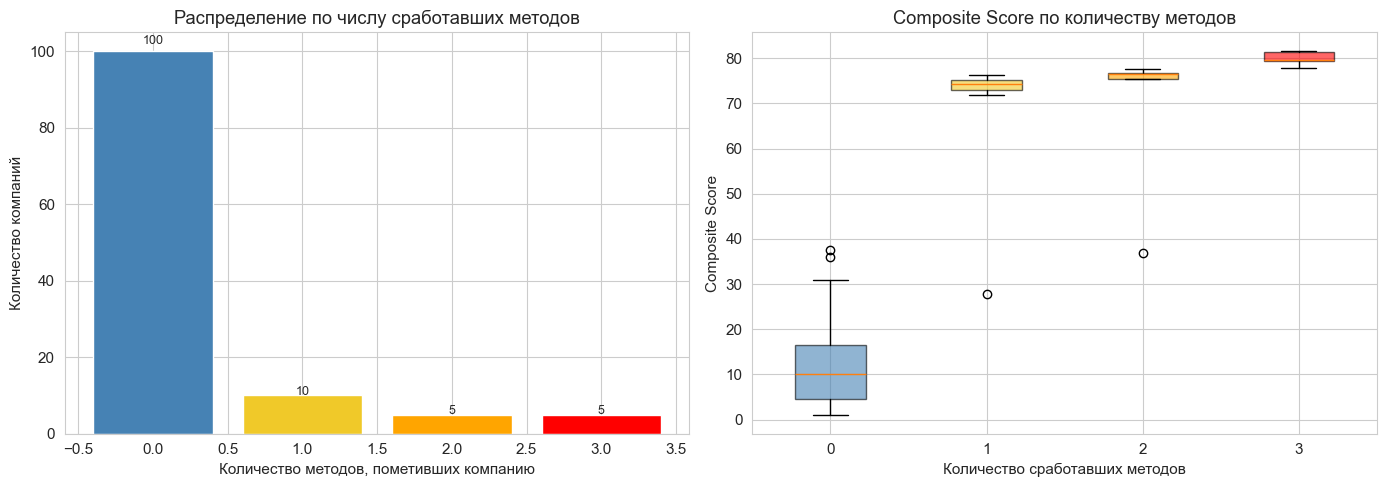

In [25]:
# ─── 9.1 Кросс-методная аналитика: согласование между методами ───

# Флаги детекции по каждому методу
df_company['det_rules'] = (df_company['rule_score'] >= 40).astype(int)
df_company['det_iso']   = (df_company['iso_score'] == -1).astype(int)
df_company['det_lof']   = (df_company['lof_pred'] == -1).astype(int)
df_company['det_dbscan'] = (df_company['dbscan_cluster'] == -1).astype(int)

df_company['n_methods_flagged'] = (
    df_company['det_rules'] + df_company['det_iso'] +
    df_company['det_lof'] + df_company['det_dbscan']
)

print("=" * 80)
print("  КРОСС-МЕТОДНАЯ АНАЛИТИКА: СОГЛАСОВАНИЕ МЕТОДОВ ДЕТЕКЦИИ")
print("=" * 80)

# Количество компаний по числу сработавших методов
print("\nКоличество компаний по числу сработавших методов:")
for n_m in range(5):
    cnt = (df_company['n_methods_flagged'] == n_m).sum()
    pct = cnt / len(df_company) * 100
    label = '(CLEAN)' if n_m == 0 else 'метод(ов)'
    print(f"  {n_m} {label:>12}: {cnt:>8,} ({pct:>6.2f}%)")

# Матрица пересечений
methods_dict = {'Rules(≥40)': 'det_rules', 'IsoForest': 'det_iso',
                'LOF': 'det_lof', 'DBSCAN': 'det_dbscan'}
print("\nМатрица пересечений (кол-во компаний):")
header = f"{'':14}" + "  ".join(f"{n:>10}" for n in methods_dict.keys())
print(header)
for m1_name, m1_col in methods_dict.items():
    row_vals = []
    for m2_name, m2_col in methods_dict.items():
        cnt = ((df_company[m1_col] == 1) & (df_company[m2_col] == 1)).sum()
        row_vals.append(f"{cnt:>10,}")
    print(f"  {m1_name:<12}" + "  ".join(row_vals))

# Высокая уверенность: 3+ метода
high_conf = df_company[df_company['n_methods_flagged'] >= 3]
print(f"\nВысокая уверенность (3+ методов): {len(high_conf):,} компаний")
if len(high_conf) > 0:
    print(f"  Средний composite_score: {high_conf['composite_score'].mean():.1f}")
    print(f"  Средний rule_score: {high_conf['rule_score'].mean():.1f}")

# Максимальная уверенность: все 4 метода
all_methods = df_company[df_company['n_methods_flagged'] == 4]
print(f"\nМаксимальная уверенность (все 4 метода): {len(all_methods):,} компаний")
if len(all_methods) > 0:
    print(f"  Средний composite_score: {all_methods['composite_score'].mean():.1f}")
    print(all_methods[['inn','org_id','composite_score','rule_score']].head(20).to_string(index=False))

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Барплот по числу методов
method_dist = df_company['n_methods_flagged'].value_counts().sort_index()
bar_colors = ['steelblue', '#f0c929', 'orange', 'red', 'darkred']
axes[0].bar(method_dist.index, method_dist.values,
            color=[bar_colors[i] for i in method_dist.index])
axes[0].set_xlabel('Количество методов, пометивших компанию')
axes[0].set_ylabel('Количество компаний')
axes[0].set_title('Распределение по числу сработавших методов')
for x, v in zip(method_dist.index, method_dist.values):
    axes[0].text(x, v + v*0.02, f'{v:,}', ha='center', fontsize=9)

# Composite Score по количеству методов (boxplot вручную)
data_by_methods = [df_company[df_company['n_methods_flagged'] == i]['composite_score'].values
                   for i in sorted(df_company['n_methods_flagged'].unique())]
bp = axes[1].boxplot(data_by_methods,
                     labels=sorted(df_company['n_methods_flagged'].unique()),
                     patch_artist=True)
for patch, color in zip(bp['boxes'], bar_colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_xlabel('Количество сработавших методов')
axes[1].set_ylabel('Composite Score')
axes[1].set_title('Composite Score по количеству методов')
plt.tight_layout()
plt.show()

  КОНЦЕНТРАЦИЯ РИСКА ПО СРЕЗАМ

Топ-15 ТБ по доле подозрительных компаний (CRITICAL+HIGH):
                 total  suspicious  mean_score  max_score  susp_pct
terbank                                                            
Северо-Западный     11           5       40.70      81.70     45.45
Юго-Западный        10           3       25.30      79.60     30.00
Дальневосточный     17           4       28.30      76.60     23.53
Байкальский         11           2       25.00      76.20     18.18
Московский          17           3       20.90      79.30     17.65
Сибирский           15           2       15.50      77.90     13.33
Центральный          8           1       12.40      36.10     12.50
Уральский           15           1       18.10      75.30      6.67
Волго-Вятский        6           0        9.50      18.10      0.00
Поволжский          10           0       11.00      21.70      0.00

Топ-15 ОКВЭД-секций по доле подозрительных:
               total  suspicious  mean_score  ma

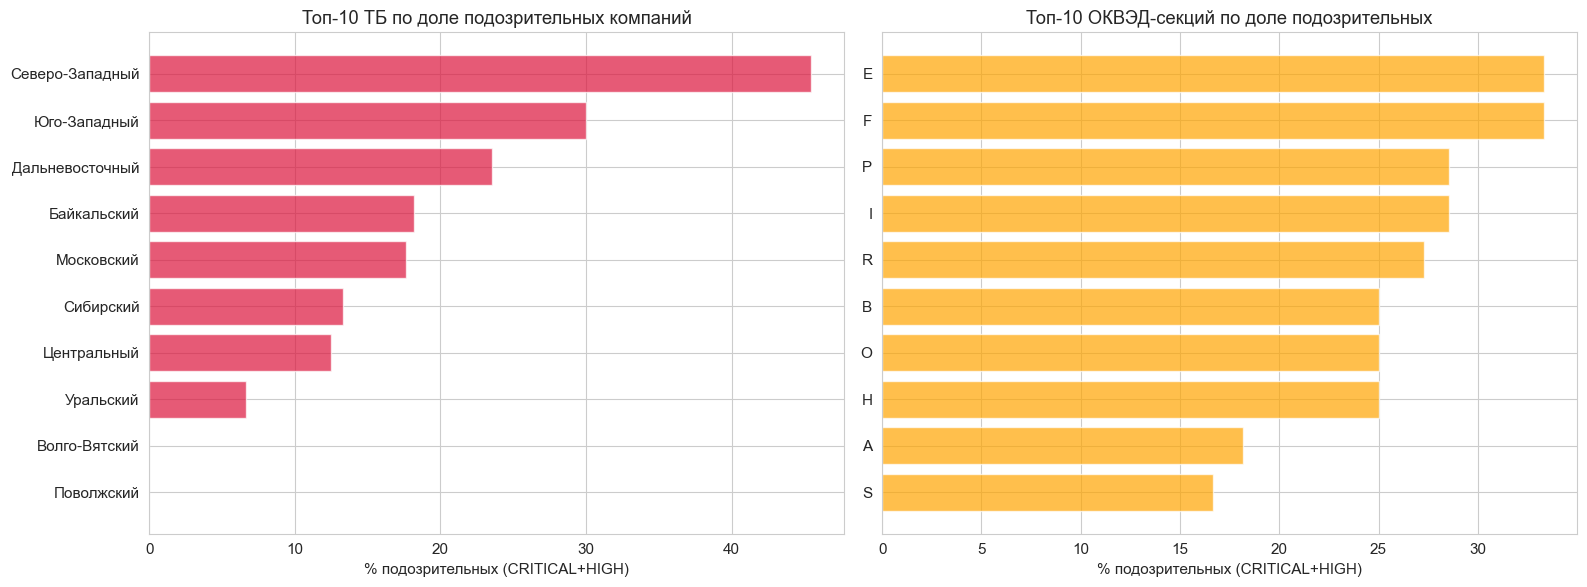

In [26]:
# ─── 9.2 Концентрация риска: ТБ, ОКВЭД, сегменты ───

print("=" * 80)
print("  КОНЦЕНТРАЦИЯ РИСКА ПО СРЕЗАМ")
print("=" * 80)

# По ТБ
if 'terbank' in df_company.columns and df_company['terbank'].notna().sum() > 0:
    tb_stats = df_company.groupby('terbank').agg(
        total=('inn', 'count'),
        suspicious=('risk_level', lambda x: x.isin(['CRITICAL','HIGH']).sum()),
        mean_score=('composite_score', 'mean'),
        max_score=('composite_score', 'max')
    ).round(1)
    tb_stats['susp_pct'] = (tb_stats['suspicious'] / tb_stats['total'] * 100).round(2)
    tb_stats = tb_stats.sort_values('susp_pct', ascending=False)
    print(f"\nТоп-15 ТБ по доле подозрительных компаний (CRITICAL+HIGH):")
    print(tb_stats.head(15).to_string())
else:
    tb_stats = pd.DataFrame()

# По ОКВЭД
if 'okved_section' in df_company.columns and df_company['okved_section'].notna().sum() > 0:
    okved_stats = df_company.groupby('okved_section').agg(
        total=('inn', 'count'),
        suspicious=('risk_level', lambda x: x.isin(['CRITICAL','HIGH']).sum()),
        mean_score=('composite_score', 'mean'),
        max_score=('composite_score', 'max')
    ).round(1)
    okved_stats['susp_pct'] = (okved_stats['suspicious'] / okved_stats['total'] * 100).round(2)
    okved_stats = okved_stats.sort_values('susp_pct', ascending=False)
    print(f"\nТоп-15 ОКВЭД-секций по доле подозрительных:")
    print(okved_stats.head(15).to_string())
else:
    okved_stats = pd.DataFrame()

# По сегменту
if 'segment_name' in df_company.columns and df_company['segment_name'].notna().sum() > 0:
    seg_stats = df_company.groupby('segment_name').agg(
        total=('inn', 'count'),
        suspicious=('risk_level', lambda x: x.isin(['CRITICAL','HIGH']).sum()),
        mean_score=('composite_score', 'mean')
    ).round(1)
    seg_stats['susp_pct'] = (seg_stats['suspicious'] / seg_stats['total'] * 100).round(2)
    seg_stats = seg_stats.sort_values('susp_pct', ascending=False)
    print(f"\nПо сегменту клиента:")
    print(seg_stats.to_string())

# По проблемной группе
if 'problem_group' in df_company.columns and df_company['problem_group'].notna().sum() > 0:
    pg_stats = df_company.groupby('problem_group').agg(
        total=('inn', 'count'),
        suspicious=('risk_level', lambda x: x.isin(['CRITICAL','HIGH']).sum()),
        mean_score=('composite_score', 'mean')
    ).round(1)
    pg_stats['susp_pct'] = (pg_stats['suspicious'] / pg_stats['total'] * 100).round(2)
    pg_stats = pg_stats.sort_values('susp_pct', ascending=False)
    print(f"\nПо проблемной группе:")
    print(pg_stats.to_string())

# Визуализации
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if len(tb_stats) > 0:
    top_tb = tb_stats.head(10)
    axes[0].barh(top_tb.index.astype(str), top_tb['susp_pct'], color='crimson', alpha=0.7)
    axes[0].set_xlabel('% подозрительных (CRITICAL+HIGH)')
    axes[0].set_title('Топ-10 ТБ по доле подозрительных компаний')
    axes[0].invert_yaxis()

if len(okved_stats) > 0:
    top_okved = okved_stats.head(10)
    axes[1].barh(top_okved.index.astype(str), top_okved['susp_pct'], color='orange', alpha=0.7)
    axes[1].set_xlabel('% подозрительных (CRITICAL+HIGH)')
    axes[1].set_title('Топ-10 ОКВЭД-секций по доле подозрительных')
    axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

  СТАТИСТИЧЕСКОЕ ПРОФИЛИРОВАНИЕ: ПОДОЗРИТЕЛЬНЫЕ vs ЧИСТЫЕ

Сравнение CRITICAL+HIGH (21) vs LOW (86):
(Mann-Whitney U тест: *** p<0.001, ** p<0.01, * p<0.05)

  debt_due_rub_last            Flagged:  42,801,369.71  |  Clean:  43,763,845.50  |  Ratio:   0.98x  n/a
  debt_ovr_rub_max             Flagged:  24,488,107.71  |  Clean:   1,040,004.64  |  Ratio:  23.55x  n/a
  exposure_amt_last            Flagged:  24,982,638.82  |  Clean:  40,853,442.38  |  Ratio:   0.61x  n/a
  limit_amt                    Flagged:  28,854,164.90  |  Clean:  46,613,427.78  |  Ratio:   0.62x  n/a
  debt_growth_ratio            Flagged:           2.08  |  Clean:           1.54  |  Ratio:   1.35x  n/a
  overdue_month_ratio          Flagged:           0.43  |  Clean:           0.16  |  Ratio:   2.73x  n/a
  debt_cv                      Flagged:           0.83  |  Clean:           0.16  |  Ratio:   5.18x  n/a
  restruct_cnt_max             Flagged:           3.57  |  Clean:           0.70  |  Ratio:   5.12x  n/a
  

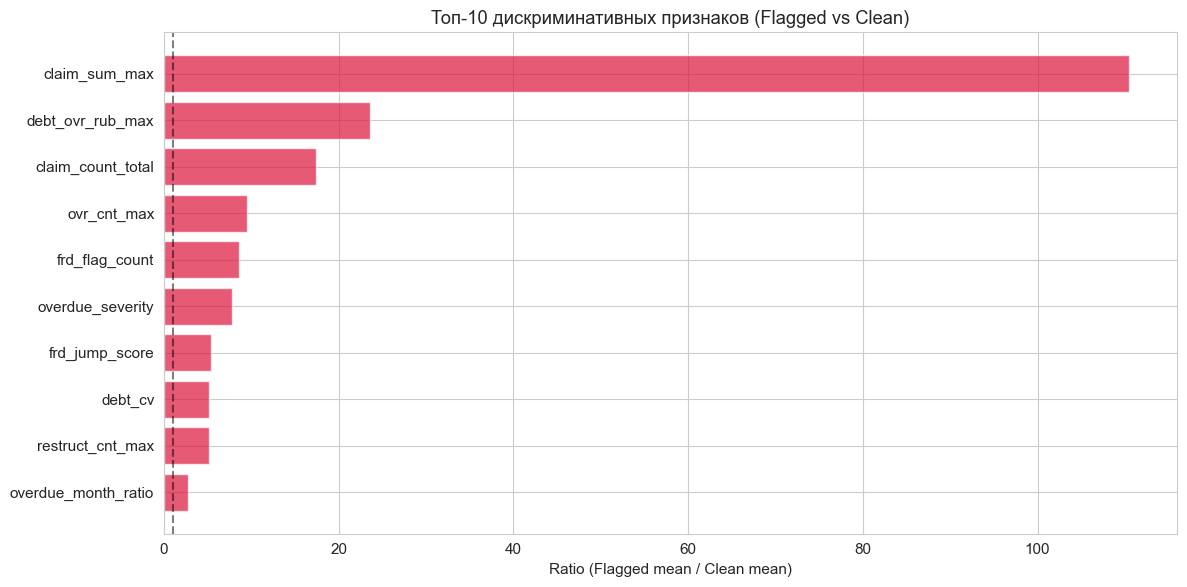

In [27]:
# ─── 9.3 Статистическое профилирование: подозрительные vs чистые ───

print("=" * 80)
print("  СТАТИСТИЧЕСКОЕ ПРОФИЛИРОВАНИЕ: ПОДОЗРИТЕЛЬНЫЕ vs ЧИСТЫЕ")
print("=" * 80)

flagged = df_company[df_company['risk_level'].isin(['CRITICAL', 'HIGH'])]
clean = df_company[df_company['risk_level'] == 'LOW']

compare_cols = [
    'debt_due_rub_last', 'debt_ovr_rub_max', 'exposure_amt_last', 'limit_amt',
    'debt_growth_ratio', 'overdue_month_ratio', 'debt_cv',
    'restruct_cnt_max', 'ovr_cnt_max', 'claim_sum_max', 'claim_count_total',
    'frd_jump_score', 'frd_flag_count', 'beneficiary_risk',
    'data_completeness', 'overdue_severity', 'fin_data_fill_ratio',
    'debt_trend_slope', 'debt_presence_ratio'
]
compare_cols = [c for c in compare_cols if c in df_company.columns]

rows = []
for col in compare_cols:
    f_vals = flagged[col].dropna()
    c_vals = clean[col].dropna()

    c_mean = c_vals.mean() if len(c_vals) > 0 else 0
    f_mean = f_vals.mean() if len(f_vals) > 0 else 0
    row = {
        'Признак': col,
        'Flagged_N': len(f_vals),
        'Flagged_mean': f_mean,
        'Flagged_median': f_vals.median() if len(f_vals) > 0 else np.nan,
        'Clean_N': len(c_vals),
        'Clean_mean': c_mean,
        'Clean_median': c_vals.median() if len(c_vals) > 0 else np.nan,
        'Ratio_mean': f_mean / c_mean if c_mean != 0 else np.nan
    }

    # Mann-Whitney U test
    if len(f_vals) > 30 and len(c_vals) > 30:
        stat, pval = mannwhitneyu(f_vals, c_vals, alternative='two-sided')
        row['p_value'] = pval
        row['Significant'] = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
    else:
        row['p_value'] = np.nan
        row['Significant'] = 'n/a'

    rows.append(row)

profile_df = pd.DataFrame(rows)
print(f"\nСравнение CRITICAL+HIGH ({len(flagged):,}) vs LOW ({len(clean):,}):")
print(f"(Mann-Whitney U тест: *** p<0.001, ** p<0.01, * p<0.05)\n")

for _, r in profile_df.iterrows():
    rr = r['Ratio_mean']
    sig = r['Significant']
    f_str = f"{r['Flagged_mean']:>14,.2f}" if pd.notna(r['Flagged_mean']) else f"{'N/A':>14}"
    c_str = f"{r['Clean_mean']:>14,.2f}" if pd.notna(r['Clean_mean']) else f"{'N/A':>14}"
    r_str = f"{rr:>6.2f}x" if pd.notna(rr) else f"{'N/A':>7}"
    print(f"  {r['Признак']:<28} Flagged: {f_str}  |  Clean: {c_str}  |  Ratio: {r_str}  {sig}")

# Топ дискриминативных признаков
profile_df['abs_ratio'] = profile_df['Ratio_mean'].apply(lambda x: abs(x - 1) if pd.notna(x) else 0)
top_disc = profile_df.nlargest(10, 'abs_ratio')
print(f"\nТоп-10 наиболее дискриминативных признаков:")
for _, r in top_disc.iterrows():
    rr = r['Ratio_mean']
    print(f"  {r['Признак']:<28}: ratio={rr:.2f}x  {r['Significant']}" if pd.notna(rr) else f"  {r['Признак']:<28}: N/A")

# Визуализация топ-10 по ratio
fig, ax = plt.subplots(figsize=(12, 6))
top_disc_plot = top_disc.sort_values('abs_ratio')
colors = ['crimson' if r > 1 else 'steelblue' for r in top_disc_plot['Ratio_mean'].fillna(1)]
ax.barh(top_disc_plot['Признак'], top_disc_plot['Ratio_mean'].fillna(1), color=colors, alpha=0.7)
ax.axvline(x=1, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Ratio (Flagged mean / Clean mean)')
ax.set_title('Топ-10 дискриминативных признаков (Flagged vs Clean)')
plt.tight_layout()
plt.show()

In [28]:
# ─── 9.4 Паттерны фрода: кластеризация подозрительных компаний ───

print("=" * 80)
print("  ПАТТЕРНЫ ФРОДА: ТИПОЛОГИЯ ПОДОЗРИТЕЛЬНЫХ КОМПАНИЙ")
print("=" * 80)

# Кластеризация подозрительных для выявления типов фрода
suspicious_idx = df_company['risk_level'].isin(['CRITICAL', 'HIGH', 'MEDIUM'])
if suspicious_idx.sum() >= 100:

    X_susp = X_scaled_df.loc[suspicious_idx].values

    # Подбираем число кластеров (от 3 до 8)
    n_fraud_clusters = min(6, max(3, suspicious_idx.sum() // 1000))
    kmeans_fraud = KMeans(n_clusters=n_fraud_clusters, random_state=42, n_init=10)
    fraud_labels = kmeans_fraud.fit_predict(X_susp)
    df_company.loc[suspicious_idx, 'fraud_pattern'] = fraud_labels

    susp_df = df_company[suspicious_idx].copy()
    print(f"\nВыявлено {n_fraud_clusters} паттернов фрода среди {suspicious_idx.sum():,} подозрительных компаний:\n")

    profile_features = ['rule_score', 'composite_score', 'debt_due_rub_last',
                        'debt_ovr_rub_max', 'frd_jump_score', 'overdue_month_ratio',
                        'restruct_cnt_max', 'claim_sum_max', 'frd_flag_count',
                        'beneficiary_risk', 'data_completeness', 'overdue_severity']
    profile_features = [f for f in profile_features if f in susp_df.columns]

    for pat in range(n_fraud_clusters):
        mask = susp_df['fraud_pattern'] == pat
        pat_df = susp_df[mask]
        print(f"─── Паттерн {pat} ({len(pat_df):,} компаний) ───")

        # Распределение по уровням риска
        rl = pat_df['risk_level'].value_counts()
        rl_str = ', '.join(f"{lev}: {cnt}" for lev, cnt in rl.items())
        print(f"  Уровни риска: {rl_str}")

        # Ключевые статистики
        for feat in profile_features:
            vals = pat_df[feat].dropna()
            if len(vals) > 0:
                print(f"  {feat:<28}: mean={vals.mean():>12,.2f}  med={vals.median():>12,.2f}")

        # Топ правил в паттерне
        rules_in_pat = []
        for reasons in pat_df['rule_reasons']:
            if reasons and str(reasons) != 'CLEAN' and str(reasons) != 'nan':
                for r in str(reasons).split('|'):
                    if ':' in r:
                        parts = r.split(':')
                        code = parts[0] + ':' + parts[1].split('=')[0].split('>')[0]
                    else:
                        code = r
                    rules_in_pat.append(code)
        if rules_in_pat:
            top5 = Counter(rules_in_pat).most_common(5)
            print(f"  Топ-5 правил: {', '.join(f'{r}({c})' for r, c in top5)}")
        print()

    # PCA визуализация паттернов
    pca_susp = PCA(n_components=2, random_state=42).fit_transform(X_susp)
    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(pca_susp[:, 0], pca_susp[:, 1],
                         c=fraud_labels, cmap='Set1', alpha=0.5, s=30, edgecolors='grey', linewidths=0.3)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Паттерны фрода среди подозрительных компаний ({n_fraud_clusters} кластеров)')
    plt.colorbar(scatter, label='Паттерн')
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно подозрительных компаний для кластеризации паттернов.")

  ПАТТЕРНЫ ФРОДА: ТИПОЛОГИЯ ПОДОЗРИТЕЛЬНЫХ КОМПАНИЙ
Недостаточно подозрительных компаний для кластеризации паттернов.


In [29]:
# ─── 9.5 Сводная числовая статистика (для передачи) ───

print("=" * 80)
print("  СВОДНАЯ ЧИСЛОВАЯ СТАТИСТИКА АНАЛИТИКИ (v3)")
print("=" * 80)

print(f"\n1. ОБЩИЕ ДАННЫЕ")
print(f"   Всего компаний (ИНН): {len(df_company):,}")
print(f"   Периодов (snapshot): {df['snapshot_date'].nunique()}")
print(f"   Всего строк: {len(df):,}")

print(f"\n2. RULE-BASED СКОРИНГ (v3, 20 правил)")
rs = df_company['rule_score']
print(f"   Score: mean={rs.mean():.2f}, median={rs.median():.1f}, std={rs.std():.2f}, max={rs.max():.0f}")
for thr in [0, 25, 40, 60]:
    cnt = (rs >= thr).sum() if thr > 0 else (rs > 0).sum()
    label = f"score > {thr}" if thr == 0 else f"score >= {thr}"
    print(f"   {label}: {cnt:,} ({cnt/len(df_company)*100:.2f}%)")

print(f"\n3. ML МОДЕЛИ")
iso_cnt = (df_company['iso_score'] == -1).sum()
lof_cnt = (df_company['lof_pred'] == -1).sum()
dbs_cnt = (df_company['dbscan_cluster'] == -1).sum()
n_cl = df_company['dbscan_cluster'].nunique()
print(f"   Isolation Forest (contamination=0.06): {iso_cnt:,} аномалий ({iso_cnt/len(df_company)*100:.2f}%)")
print(f"   LOF (n_neighbors=50, contamination=0.06): {lof_cnt:,} аномалий ({lof_cnt/len(df_company)*100:.2f}%)")
print(f"   DBSCAN (min_samples=10, PCA=15): {n_cl} кластеров, шум: {dbs_cnt:,} ({dbs_cnt/len(df_company)*100:.2f}%)")

print(f"\n4. COMPOSITE SCORE (v3)")
print(f"   Веса: Rules={W_RULES}, ISO={W_ISO}, LOF={W_LOF}, DBSCAN={W_DBSCAN}")
cs = df_company['composite_score']
print(f"   Score: mean={cs.mean():.2f}, median={cs.median():.1f}, std={cs.std():.2f}, "
      f"max={cs.max():.1f}, p95={cs.quantile(0.95):.1f}, p99={cs.quantile(0.99):.1f}")
cw = df_company['confidence_weight']
print(f"   Confidence weight: mean={cw.mean():.3f}, <1.0: {(cw < 1.0).sum():,} компаний")
for level in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
    cnt = (df_company['risk_level'] == level).sum()
    pct = cnt / len(df_company) * 100
    print(f"   {level:<10}: {cnt:>8,} ({pct:>6.2f}%)")

print(f"\n5. КРОСС-МЕТОДНОЕ СОГЛАСОВАНИЕ")
for n_m in range(5):
    cnt = (df_company['n_methods_flagged'] == n_m).sum()
    pct = cnt / len(df_company) * 100
    print(f"   {n_m} методов: {cnt:>8,} ({pct:>6.2f}%)")

print(f"\n6. TOP-10 FEATURE IMPORTANCE (Isolation Forest)")
importances_sorted = pd.Series(
    np.mean([tree.feature_importances_ for tree in iso_forest.estimators_], axis=0),
    index=ml_features
).sort_values(ascending=False)
for feat, imp in importances_sorted.head(10).items():
    print(f"   {feat:<35}: {imp:.4f}")

print(f"\n7. КЛЮЧЕВЫЕ ПРИЗНАКИ ПО УРОВНЮ РИСКА")
key_profile_cols = ['frd_jump_score', 'overdue_severity', 'frd_flag_count',
                    'beneficiary_risk', 'data_completeness', 'problem_group_ordinal',
                    'claim_sum_max', 'debt_due_rub_last']
key_profile_cols = [c for c in key_profile_cols if c in df_company.columns]

header = f"   {'Признак':<28}" + "".join(f"{'  ' + lev:>12}" for lev in ['CRITICAL','HIGH','MEDIUM','LOW'])
print(header)
for col in key_profile_cols:
    vals = []
    for lev in ['CRITICAL', 'HIGH', 'MEDIUM', 'LOW']:
        v = df_company[df_company['risk_level'] == lev][col].mean()
        vals.append(f"{v:>12.3f}" if pd.notna(v) else f"{'N/A':>12}")
    print(f"   {col:<28}" + "".join(vals))

print(f"\n8. НОВЫЕ/ИСПРАВЛЕННЫЕ ПРИЗНАКИ v3 — СТАТИСТИКА")
new_feats = ['data_completeness', 'fin_data_fill_ratio', 'beneficiary_risk',
             'overdue_severity', 'expo_debt_mismatch', 'reserv_expo_anomaly',
             'zero_debt_anomaly', 'frd_susp_binary', 'debt_to_limit',
             'ovr_to_debt_ratio', 'claims_intensity',
             'debt_presence_ratio', 'problem_group_ordinal',
             'has_ben_0', 'has_ben_1', 'has_ben_3', 'has_ben_5',
             'confidence_weight']
new_feats = [f for f in new_feats if f in df_company.columns]
for f in new_feats:
    vals = df_company[f].dropna()
    if len(vals) > 0:
        print(f"   {f:<28}: mean={vals.mean():>10.4f}  std={vals.std():>10.4f}  "
              f"nonzero={((vals != 0).sum()):,} ({(vals != 0).sum()/len(df_company)*100:.1f}%)")

print(f"\n9. ИСПРАВЛЕНИЯ v3")
print(f"   - R19 (zero_debt_anomaly): требует fin_data_fill_ratio > 0.1")
print(f"     zero_debt_anomaly fires: {df_company['zero_debt_anomaly'].sum():,} "
      f"({df_company['zero_debt_anomaly'].sum()/len(df_company)*100:.2f}%)")
print(f"   - ben_0..5 заменены на has_ben_* бинарные флаги")
print(f"   - Удалены {len(['ovr_cnt_max','max_ovr_to_limit','had_restruct','overdue_trend','frd_confirmed','debt_trend_slope','frd_owner_changed_1y','log_debt_ovr_rub_max','log_debt_ovr_rub_sum','log_overdue_od_max','months_with_overdue','overdue_month_ratio','restruct_cnt_max'])} бесполезных ML-признаков (<5% nonzero)")
print(f"   - LOF вес: 0.20 → 0.10 (детектил разреженность, не фрод)")
print(f"   - Confidence weighting: composite *= min(1, completeness/0.5)")
print(f"   - problem_group_ordinal добавлен в ML")

print(f"\n{'='*80}")
print(f"  Аналитика v3 завершена. Результаты экспортируются в CSV.")
print(f"{'='*80}")

  СВОДНАЯ ЧИСЛОВАЯ СТАТИСТИКА АНАЛИТИКИ (v3)

1. ОБЩИЕ ДАННЫЕ
   Всего компаний (ИНН): 120
   Периодов (snapshot): 27
   Всего строк: 3,240

2. RULE-BASED СКОРИНГ (v3, 20 правил)
   Score: mean=22.83, median=9.5, std=33.31, max=100
   score > 0: 118 (98.33%)
   score >= 25: 24 (20.00%)
   score >= 40: 18 (15.00%)
   score >= 60: 18 (15.00%)

3. ML МОДЕЛИ
   Isolation Forest (contamination=0.06): 8 аномалий (6.67%)
   LOF (n_neighbors=50, contamination=0.06): 8 аномалий (6.67%)
   DBSCAN (min_samples=10, PCA=15): 2 кластеров, шум: 1 (0.83%)

4. COMPOSITE SCORE (v3)
   Веса: Rules=0.45, ISO=0.3, LOF=0.1, DBSCAN=0.15
   Score: mean=21.53, median=11.8, std=24.45, max=81.7, p95=76.8, p99=81.0
   Confidence weight: mean=1.000, <1.0: 0 компаний
   CRITICAL  :       18 ( 15.00%)
   HIGH      :        3 (  2.50%)
   MEDIUM    :       13 ( 10.83%)
   LOW       :       86 ( 71.67%)

5. КРОСС-МЕТОДНОЕ СОГЛАСОВАНИЕ
   0 методов:      100 ( 83.33%)
   1 методов:       10 (  8.33%)
   2 методов:     

In [35]:
# ─── [ТЕСТ] Оценка качества моделей (только при наличии ground truth) ───
# Эта ячейка работает только с тестовыми данными, где известны истинные метки.
# Для проверки нужно перезаписать _is_fraud из сохранённой генерации.

# Загружаем ground truth из test_data генерации (если доступен)
test_gt_path = RAW_DATA_DIR / 'test_gt.csv'
_gt_available = False

if test_gt_path.exists():
    _gt = pd.read_csv(test_gt_path, sep=';')
    _gt_map = dict(zip(_gt['inn'].astype(str), _gt['_is_fraud']))
    df_company['_is_fraud'] = df_company['inn'].astype(str).map(_gt_map).fillna(0).astype(int)
    _gt_available = True

if _gt_available and df_company['_is_fraud'].sum() > 0:
    from sklearn.metrics import precision_score, recall_score, f1_score

    print("=" * 70)
    print("  [ТЕСТ] МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ (vs Ground Truth)")
    print("=" * 70)

    y_true = df_company['_is_fraud'].values
    methods = {
        'Rule-based (score>=40)': (df_company['rule_score'] >= 40).astype(int).values,
        'Isolation Forest': (df_company['iso_score'] == -1).astype(int).values,
        'LOF': (df_company['lof_pred'] == -1).astype(int).values,
        'DBSCAN (noise)': (df_company['dbscan_cluster'] == -1).astype(int).values,
        'Composite (>=35)': (df_company['composite_score'] >= 35).astype(int).values,
        'Composite (>=20)': (df_company['composite_score'] >= 20).astype(int).values,
    }

    metrics_rows = []
    for name, y_pred in methods.items():
        p = precision_score(y_true, y_pred, zero_division=0)
        r = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        detected = y_pred.sum()
        true_pos = ((y_pred == 1) & (y_true == 1)).sum()
        metrics_rows.append({
            'Метод': name, 'Detected': detected, 'True Positives': true_pos,
            'Precision': f'{p:.1%}', 'Recall': f'{r:.1%}', 'F1': f'{f1:.1%}'
        })

    metrics_df = pd.DataFrame(metrics_rows)
    print(metrics_df.to_string(index=False))
    
    # Убираем тестовый столбец
    df_company.drop(columns=['_is_fraud'], inplace=True, errors='ignore')
else:
    print(f"Ground truth ({test_gt_path}) не найден — пропускаем оценку качества.")
    print("Это нормально при работе с реальными данными.")

  [ТЕСТ] МЕТРИКИ КАЧЕСТВА МОДЕЛЕЙ (vs Ground Truth)
                 Метод  Detected  True Positives Precision Recall     F1
Rule-based (score>=40)        18              18    100.0% 100.0% 100.0%
      Isolation Forest         8               8    100.0%  44.4%  61.5%
                   LOF         8               6     75.0%  33.3%  46.2%
        DBSCAN (noise)         1               0      0.0%   0.0%   0.0%
      Composite (>=35)        21              18     85.7% 100.0%  92.3%
      Composite (>=20)        34              18     52.9% 100.0%  69.2%


In [36]:
# ─── Экспорт результатов ───
export_cols = ['inn','org_id','okved_section','org_sector','segment_name','reg_region',
               'terbank','risk_segment','liquidation','problem_group',
               'composite_score','risk_level','rule_score',
               'iso_score_norm','lof_score_norm','dbscan_cluster',
               'n_methods_flagged',
               'debt_due_rub_last','debt_ovr_rub_max','exposure_amt_last','limit_amt',
               'restruct_cnt_max','ovr_cnt_max','had_default','in_default_now',
               'frd_jump_score','max_growth_pct','had_claims','claim_sum_max',
               'was_in_frd_registry','frd_confirmed',
               'data_completeness','beneficiary_risk','overdue_severity',
               'frd_flag_count','debt_trend_slope',
               'all_reasons']
export_cols = [c for c in export_cols if c in df_company.columns]

fraud_scores_path = PROCESSED_DATA_DIR / 'fraud_scores_all.csv'
suspicious_path = PROCESSED_DATA_DIR / 'suspicious_companies.csv'

# Все компании с скоринговыми метками
df_company[export_cols].sort_values('composite_score', ascending=False).to_csv(
    fraud_scores_path, index=False, sep=';'
 )
# Только подозрительные
result_cols_export = [c for c in result_cols if c in suspicious.columns]
suspicious[result_cols_export].to_csv(suspicious_path, index=False, sep=';')

print("Экспортировано:")
print(f"  {fraud_scores_path} — все {len(df_company):,} компании с фрод-скором")
print(f"  {suspicious_path} — {len(suspicious):,} подозрительных компаний")
print(f"\nАналитика завершена.")

Экспортировано:
  C:\Users\Egor\Desktop\hseml-group-project-gorg1t\data\processed\fraud_scores_all.csv — все 120 компании с фрод-скором
  C:\Users\Egor\Desktop\hseml-group-project-gorg1t\data\processed\suspicious_companies.csv — 34 подозрительных компаний

Аналитика завершена.
